<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/gradient-collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

...intro...

In [2]:
# Install Training Instrumentation Toolkit
# (locked to specific git revision so this notebook always works)
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
  !cd training-instrumentation-toolkit && git checkout 2d806af
sys.path.append('training-instrumentation-toolkit')

# Imports
import train_instrumentation as tinstr
import train_explainer as texpl
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1372, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 1372 (delta 73), reused 45 (delta 22), pack-reused 1239 (from 1)
Receiving objects: 100% (1372/1372), 98.65 MiB | 26.92 MiB/s, done.
Resolving deltas: 100% (822/822), done.
Note: switching to '2d806af'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 2d806af Use full variable.path for plot label, works for mul

## Dataset Pipeline

..todo..intro

explain dataset


In [3]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


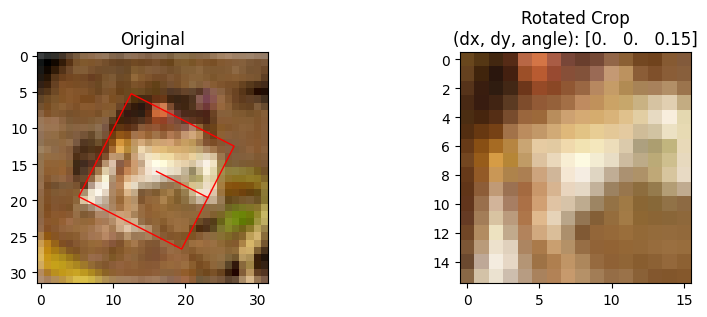

In [4]:
# image manipulation function
def rotated_crop(image, dx, dy, da):
    """
    Takes a 50% crop of the source image after applying a positional and angular
    offset relative to the image's centre.
    For example, (dx,dy,da) = (-0.25,0,0.5) will take a crop centred one quarter
    of the image width to the left from the source image centre and rotated
    45 degrees (50% of 180 in whichever direction the positive direction happens
    to take).
    Args:
      image: source image
      dx: float in range -0.5 .. +0.5 (fraction of width)
      dy: float in range -0.5 .. +0.5 (fraction of height)
      da: float in range -1.0 .. +1.0 (fraction of radians)
    Returns:
      cropped image
    """
    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    img_centre_x = img_width // 2
    img_centre_y = img_height // 2
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    crop_centre_x = crop_size // 2
    crop_centre_y = crop_size // 2

    # Step 1: Rotate crop window about its top-left corner
    # - assuming crop-mid is at (x,y)=(8,8)
    # - net result is that the crop-mid will move to crop_mid' = tf.linalg.matvec(R, crop_mid)
    R = tf.stack([
        [tf.cos(da * np.pi), -tf.sin(da * np.pi), 0],
        [tf.sin(da * np.pi), tf.cos(da * np.pi), 0],
        [0.0, 0.0, 1.0]
    ])
    R_neg = tf.stack([
        [tf.cos(-da * np.pi), -tf.sin(-da * np.pi), 0],
        [tf.sin(-da * np.pi), tf.cos(-da * np.pi), 0],
        [0.0, 0.0, 1.0]
    ])

    # Step 2a: Calculate crop-mid after rotation
    crop_mid = [crop_centre_x, crop_centre_y, 1.]
    crop_mid = tf.linalg.matvec(R, crop_mid)

    # Step 2b: Translate rotated location of crop-mid back to it's original position
    Tv = [crop_centre_x - crop_mid[0], crop_centre_y - crop_mid[1], 1.]

    # Step 2c: translate crop-mid to target location on source image
    tx = img_centre_x + dx * img_width - crop_centre_x
    ty = img_centre_y + dy * img_height - crop_centre_y
    Tv = [Tv[0] + tx, Tv[1] + ty, 1.]

    # Step 2d: reverse rotation impact before applying
    # - we'll apply the translation first, so it's ultimate effect is then rotated,
    #   so we counteract that effect by pre-rotating in the opposite direction
    Tv = tf.linalg.matvec(R_neg, Tv)
    T = tf.stack([
        [1.0, 0.0, Tv[0]],
        [0.0, 1.0, Tv[1]],
        [0.0, 0.0, 1.0]
    ])

    # combine transformations: R * T
    # - technically this is applying T first, and then R
    # - has effect of rotating crop window by R, and then translating by R(T)
    h_matrix = tf.linalg.matmul(R, T)

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    return rotated_crop

def draw_crop_template(image, transform):
  dx, dy, da = transform
  centre_x = image.shape[1] * (0.5 + dx)
  centre_y = image.shape[0] * (0.5 + dy)
  width = image.shape[1] // 2
  height = image.shape[0] // 2
  radians = da * np.pi

  # draw a rectangle showing the outline of where the crop was taken from
  ax = plt.gca()
  rect = patches.Rectangle((centre_x - width/2, centre_y - height/2), width, height, linewidth=1, edgecolor='r', facecolor='none')
  t = transforms.Affine2D().rotate_deg_around(centre_x, centre_y, radians * 180 / np.pi)
  rect.set_transform(t + ax.transData)
  ax.add_patch(rect)

  # draw a rotated 0-degrees line to indicate the rotation.
  line_end_x = centre_x + width / 2
  line_end_y = centre_y
  rotated_endpoint = t.transform([(line_end_x, line_end_y)])[0]
  ax.plot([centre_x, rotated_endpoint[0]], [centre_y, rotated_endpoint[1]], color='r', linewidth=1)

def show_data_sample(inputs, output):
  (image, cropped) = inputs
  transform = output
  plt.figure(figsize=(10, 3))

  plt.subplot(1, 2, 1)
  plt.title("Original")
  plt.imshow(image)
  draw_crop_template(image, transform)

  plt.subplot(1, 2, 2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
  plt.show()

image = x_train[0]
transform = tf.constant(([0.0, 0.0, 0.15]))
cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
show_data_sample((image, cropped), transform)

Original shape: (32, 32, 32, 3)
Rotated Crop shape: (32, 16, 16, 3)
Transformation shape: (32, 3)


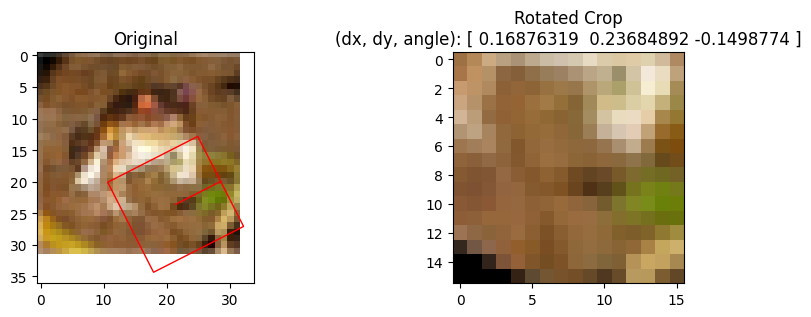

Time for 100 batches: 0.89 seconds
Total batches: 1563


In [5]:
# pre-processing pipeline
def preprocess_image(image):
    # Generate random translation and rotation
    # - dx/dy in range -0.5..+0.5 (fraction of width/height)
    # - da    in range -1.0..+1.0 (radians)
    # - small stddev
    dx = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    dy = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    da = tf.clip_by_value(tf.random.normal([], mean=0, stddev=1.0/4), -1.0, 1.0)

    # Take rotated crop
    cropped = rotated_crop(image, dx, dy, da)

    # construct as input/output tuples
    transform = tf.stack([dx, dy, da])
    return (image, cropped), transform

def prepared_dataset():
  train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
  train_dataset = train_dataset.map(
      preprocess_image,
      num_parallel_calls=tf.data.AUTOTUNE
  )
  return train_dataset

# Create the dataset pipeline
train_dataset = prepared_dataset().batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, cropped), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", cropped.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    show_data_sample((original[0], cropped[0]), transform[0])

# Optional: Time the pipeline
import time
start = time.time()
for _ in train_dataset.take(100):  # Process 100 batches
    pass
print(f"Time for 100 batches: {time.time() - start:.2f} seconds")
print(f"Total batches: {len(train_dataset)}")

## Model
We're going to train a fairly simple CNN for this problem. In their relatively translated and rotated state, the two input images are more or less independent, so we'll have two independent input arms, one for each of the two input images. Each input arm will follow a fairly typical CNN downsampling architecture that results in a low-resolution / high-feature-dimension image at the end. Then we'll concatenate the two feature sets and run a series of fully connected layers before computing the final output as a 3-vector.

The layers will exclusively use ReLU activation, except for the final output layer which will use a linear activation function as we're looking for outputs in a simple linear range.

There are a number of problems with this simplistic CNN approach for the given problem domain, as we'll shortly see. But it's a good example to illustrate the extreme of neuron death, and what can be done to aleviate the problem.

In [6]:
def baseline_conv_model():
    original_input = tf.keras.Input(shape=(32, 32, 3), name="original_image")
    crop_input = tf.keras.Input(shape=(16, 16, 3), name="crop")

    # A CNN stack for the 32x32 original image
    # - 32x32x3 -> 16x16x8 -> 8x8x16 -> 4x4x32 -> 2x2x64 -> 256 -> 128
    x1 = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1a')(original_input)
    x1 = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_1')(x1)
    x1 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2a')(x1)
    x1 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_2')(x1)
    x1 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_3a')(x1)
    x1 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_3b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_3')(x1)
    x1 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_4a')(x1)
    x1 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_4b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_4')(x1)
    x1 = layers.Flatten(name='x1_flatten')(x1)
    x1 = layers.Dense(128, activation='relu', name='x1_dense_1')(x1)

    # Separate CNN stack for the 16x16 cropped input
    # - 16x16x3 -> 8x8x16 -> 4x4x32 -> 2x2x64 -> 256 -> 128
    x2 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1b')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_1')(x2)
    x2 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_2a')(x2)
    x2 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_2b')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_2')(x2)
    x2 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_3a')(x2)
    x2 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_3b')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_3')(x2)
    x2 = layers.Flatten(name='x2_flatten')(x2)
    x2 = layers.Dense(128, activation='relu', name='x2_dense_1')(x2)

    # Combined path
    # - 128 + 128 -> 256 -> 3 (dx, dy, da)
    out = layers.Concatenate(name='head_concat1')([x1, x2])
    out = layers.Dense(256, activation='relu', name='head_dense1')(out)
    out = layers.Dense(256, activation='relu', name='head_dense2')(out)
    out = layers.Dense(3, activation='linear', name='head_dense3')(out)

    return tf.keras.Model(inputs=[original_input, crop_input], outputs=out)

# Uncomment if you just want to see the model summary
baseline_conv_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ original_image            │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1a (Conv2D)     │ (None, 32, 32, 8)      │            224 │ original_image[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1b (Conv2D)     │ (None, 32, 32, 8)      │            584 │ x1_conv2d_1a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_1               │ (None, 16, 16, 8)      │              0 │ x1_conv2d_1b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ crop (InputLayer)         │ (None, 16, 16, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2a (Conv2D)     │ (None, 16, 16, 16)     │          1,168 │ x1_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1a (Conv2D)     │ (None, 16, 16, 16)     │            448 │ crop[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2b (Conv2D)     │ (None, 16, 16, 16)     │          2,320 │ x1_conv2d_2a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1b (Conv2D)     │ (None, 16, 16, 16)     │          2,320 │ x2_conv2d_1a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_2               │ (None, 8, 8, 16)       │              0 │ x1_conv2d_2b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_pool2d_1               │ (None, 8, 8, 16)       │              0 │ x2_conv2d_1b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_3a (Conv2D)     │ (None, 8, 8, 32)       │          4,640 │ x1_pool2d_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_2a (Conv2D)     │ (None, 8, 8, 32)       │          4,640 │ x2_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_3b (Conv2D)     │ (None, 8, 8, 32)       │          9,248 │ x1_conv2d_3a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_2b (Conv2D)     │ (None, 8, 8, 32)       │          9,248 │ x2_conv2d_2a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_3               │ (None, 4, 4, 32)       │              0 │ x1_conv2d_3b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_pool2d_2               │ (None, 4, 4, 32)       │              0 │ x2_conv2d_2b[0][0]     │
│ (MaxPooling2D)       

 Total params: 343,835 (1.31 MB)

 Trainable params: 343,835 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = baseline_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=50, callbacks=[tinstr.HistoryStats()])

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0320
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0311
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0299
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0314
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0313
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0303
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0312
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0313
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0301
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0303
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0303
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0325
Epoch 13/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0315
Epoch 14/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0313
Epoch 15/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s

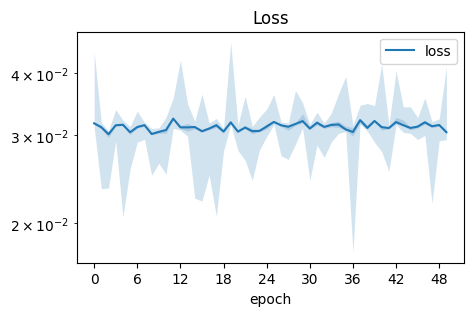

In [ ]:
tinstr.plot_train_history(history)

**Commentary:**

* Notice that the loss remains stagnant throughout training. The model is not learning.
* Recall also that loss is calculated as MSE on the dx, dy, and da components, and the dx/dy components are in the range -0.5 .. +0.5, as fractions of the original image width/height. So a loss of 0.03 can translate as $\sqrt{0.03}$ = 17.3% of the original width. That's a very large error.


If loss was the only tool available to you, then you'd be left guessing as to the cause. You might even think there's a bug in the loss calculation itself .... but you'd be wrong.

Let's get some more detailed and deeper analytics into the training behaviour, and see what's really going on.



## Instrumented Training
To investigate, we'll add some initial instrumentation to collect stats on the distributions of variable values (ie: the weights and biases), gradients, layer outputs, and layer output gradients during each epoch.

Note that instrumentation slows down training time, and we've seen that the training behaviour doesn't change much over the course of 50 epochs, so we'll just train for the first 10 epochs this time.

In [ ]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = baseline_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=10, callbacks=[variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - loss: 0.0317
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0307
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0317
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0308
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0308
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0317
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0313
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0316
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0325
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0304


First we'll get an overview...

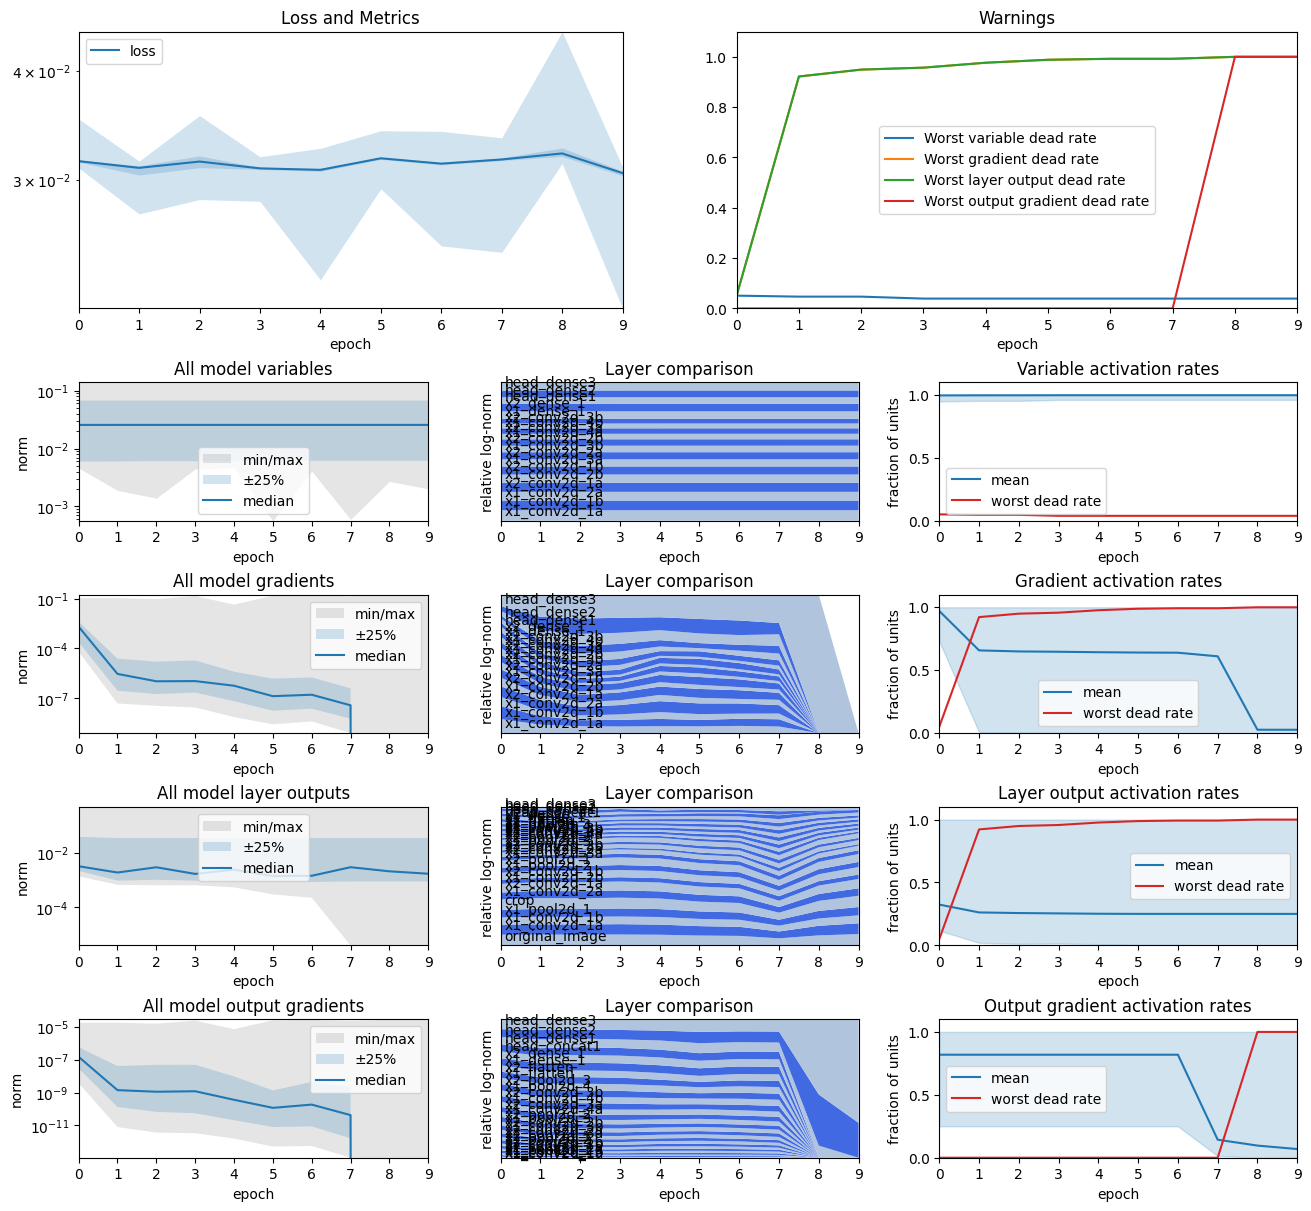

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

**Commentary**

There's something very wrong with the gradients. Let's look closer...

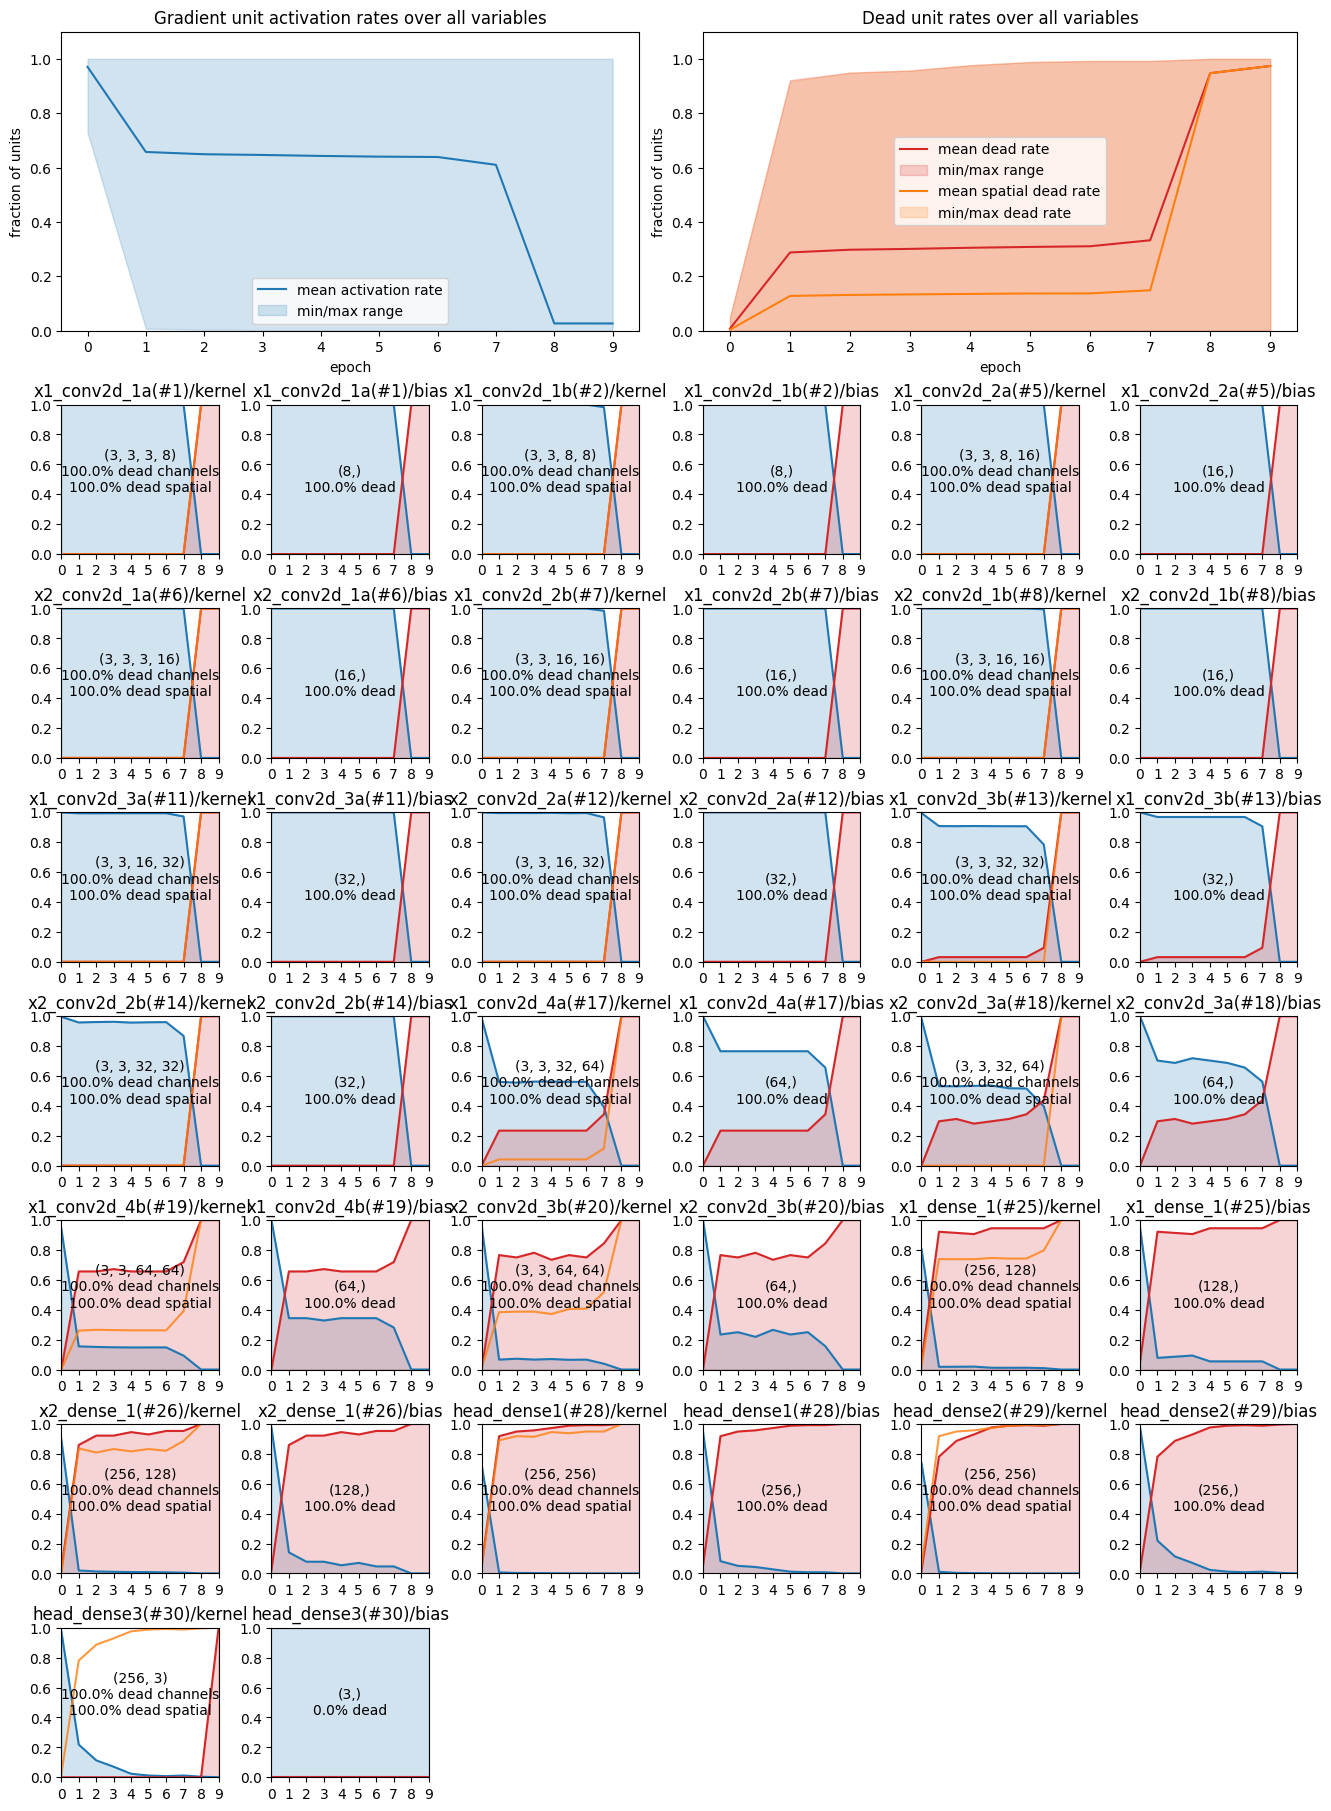

In [ ]:
tinstr.plot_activity_history(gradients)

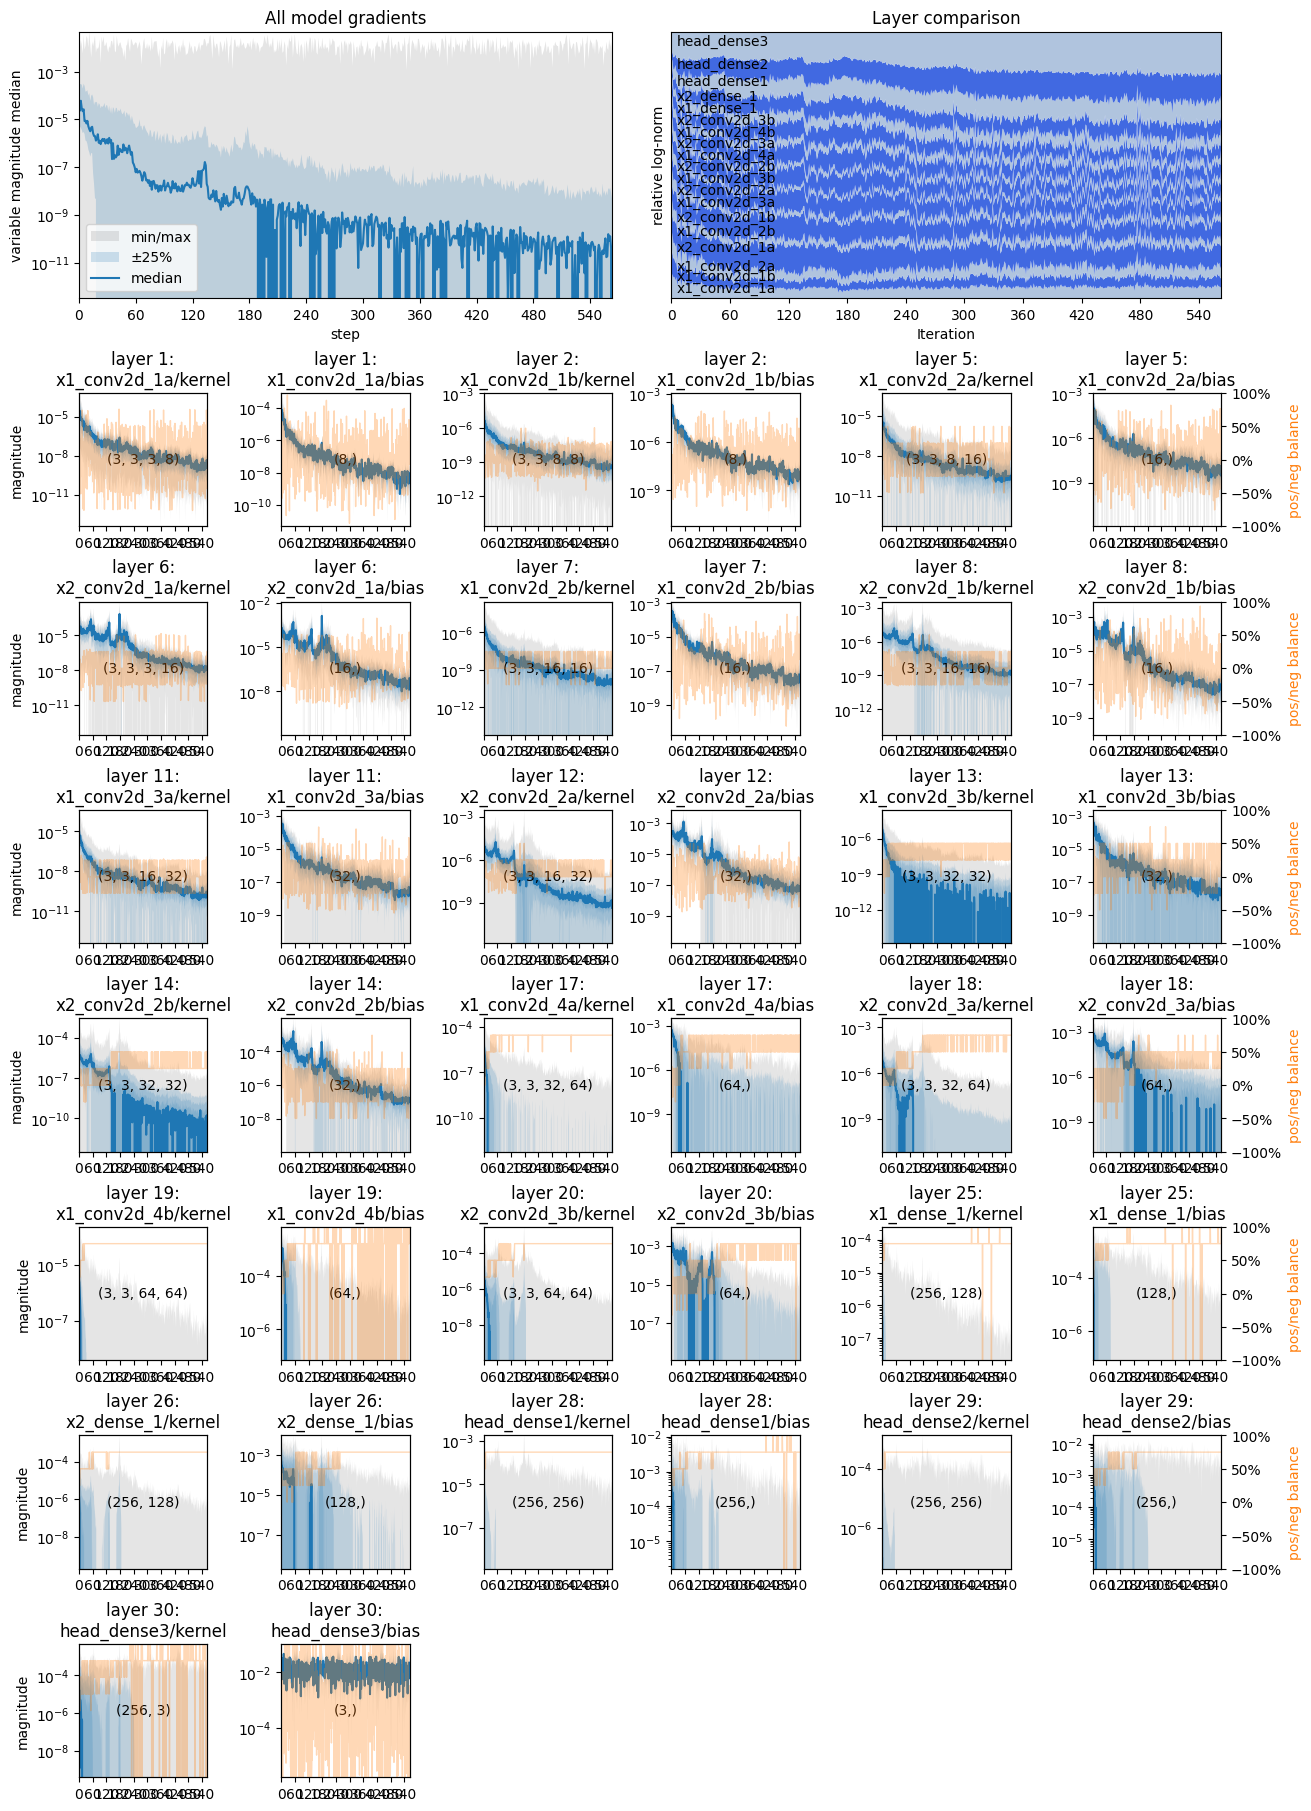

In [102]:
tinstr.plot_value_history(gradients)

**Commentary**

* This illustrates an extreme case of neuron death - where some layers actually reach 100% dead neurons. At that point learning stops and it can never recover.
* But notice how aggressive it is - in the space of a single epoch, some of the layers jump to 80%+ neuron death. It's bad news from the first epoch.


## Troubleshooting
There's so much going on in the activity plots above that it can be hard to know where to start.

Here's some initial observations and some pointers for interpreting the results:
* Firstly, in an extreme case like this, I initially ignore the activity rates and look only at the percentage of dead channels. Secondly, I start at the end of the network, closest to the loss calculation.
* Notice that the very last layer behaves well. It has 0% dead channels for most of the initial epochs. So gradients are still passing from the loss through this very first layer.
* The immediately previous layer, on the other hand, does very badly, jumping to 80% dead channels in the first epoch.
* This gives us one boundary of the region of problem - the second to last layer of the network, and it appears strongly on the first epoch.
* Now I go to the start of the network and look for the first layer that shows signs of a correlative increase in dead channels on the first epoch. In this case we're looking at `conv2d_4a` of the x1 input arm, and `conv2d_3a` of the x2 input. These are both the first layer of the last down block of their respective input arms.
* Notice that while earlier layers do eventually experience neuron death, they do so later on in training, and so they are easy to rule out as side-effects rather than cause.

Plotting the gradients gives us information about the information flow from the last layer towards the first.

By plotting the layer outputs, we can get information about how information flows through the model from the first layer towards the last. Let's do that now....

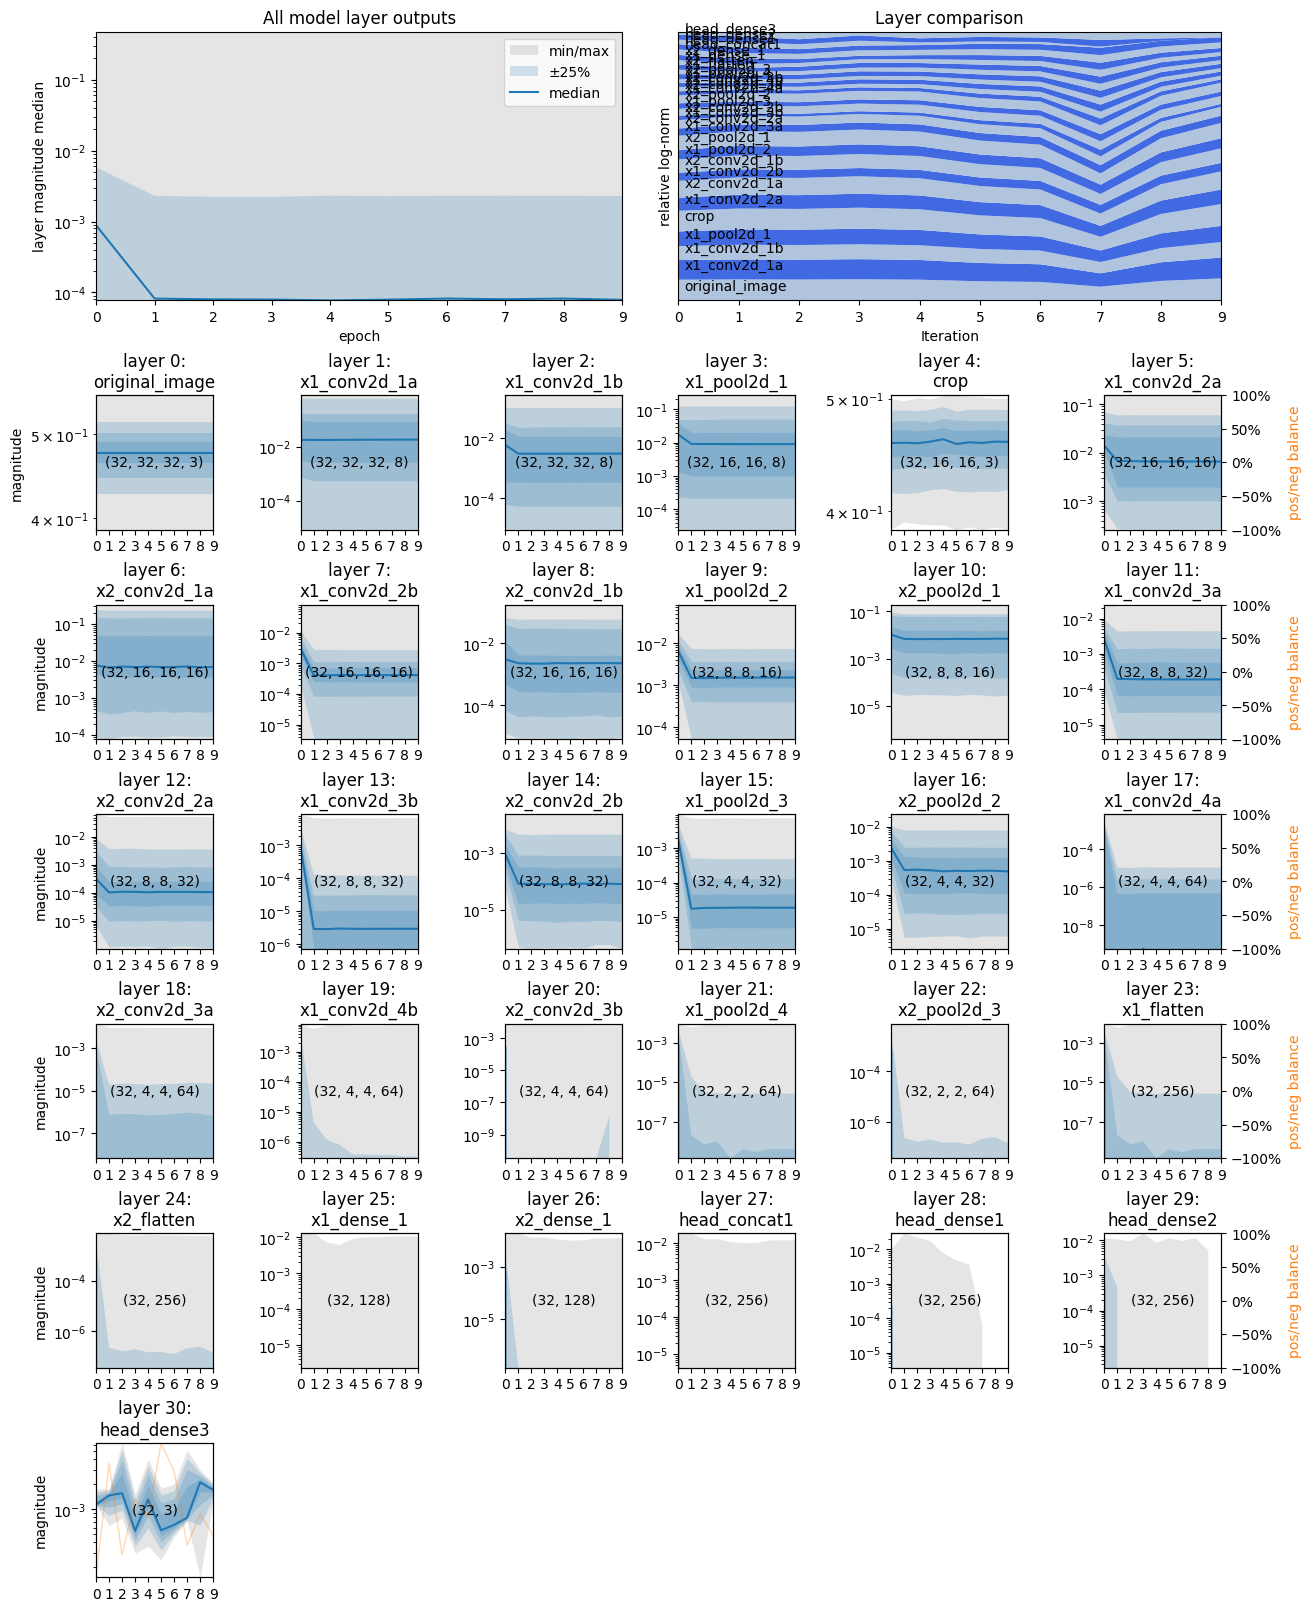

In [ ]:
tinstr.plot_value_history(outputs)

**Commentary**

There's a couple of concerning points there:
* the flat lines don't look good. There should be some variation. The fact that the output values are so stable suggests no learning is going on.
* the later layers look like they've dropped to zero output.

Let's look at the activity rates of the layer outputs...

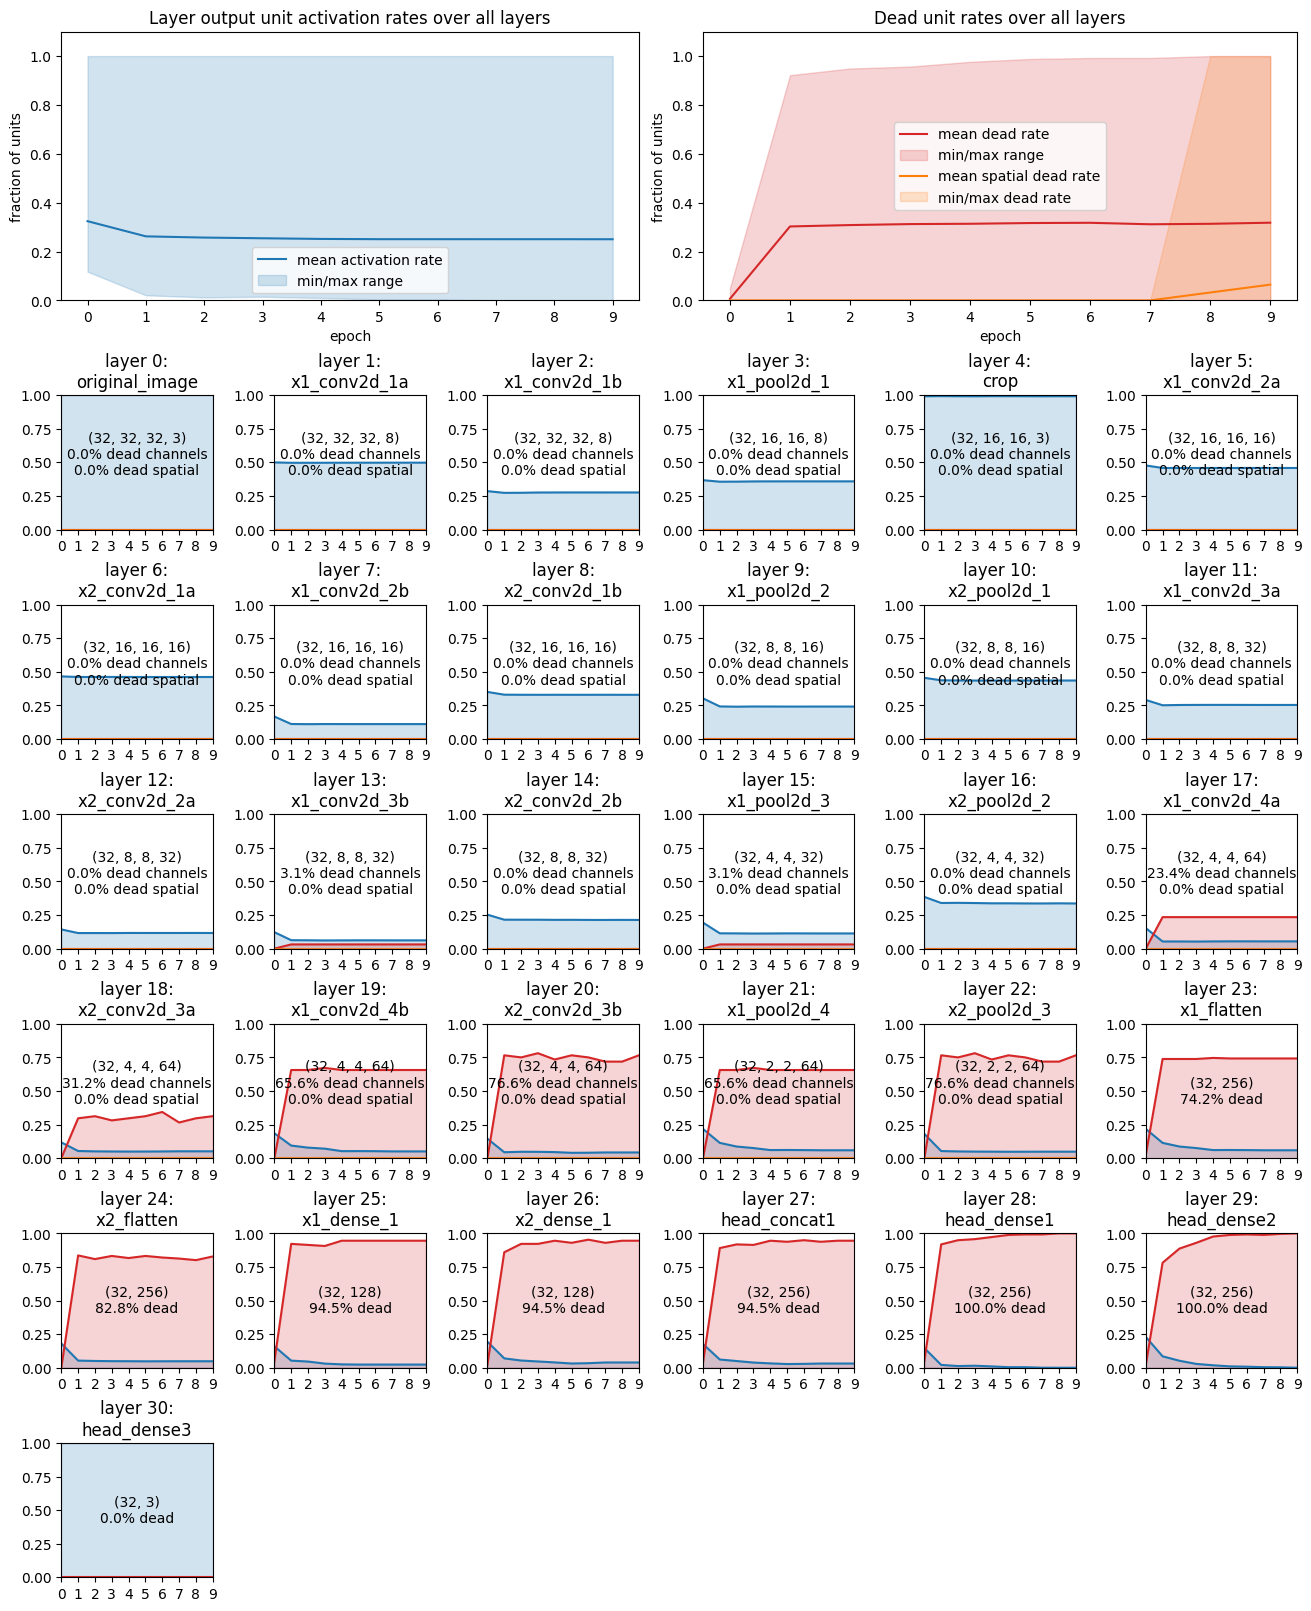

In [ ]:
tinstr.plot_activity_history(outputs)

**Commentary**

* The earlier layers don't suffer from neuron death at first, but there's something more subitle worth noticing. The very first conv layer of both the x1 and x2 input arm remain at 50% activity throughout. That's very unusual.
* Also notice that `x1_conv2d_2b` drops as low as 20% by epoch 1, and that `x1_conv2d_3b` is even worse.
* Is this because the weights are close to zero?

Let's quickly check the weights...

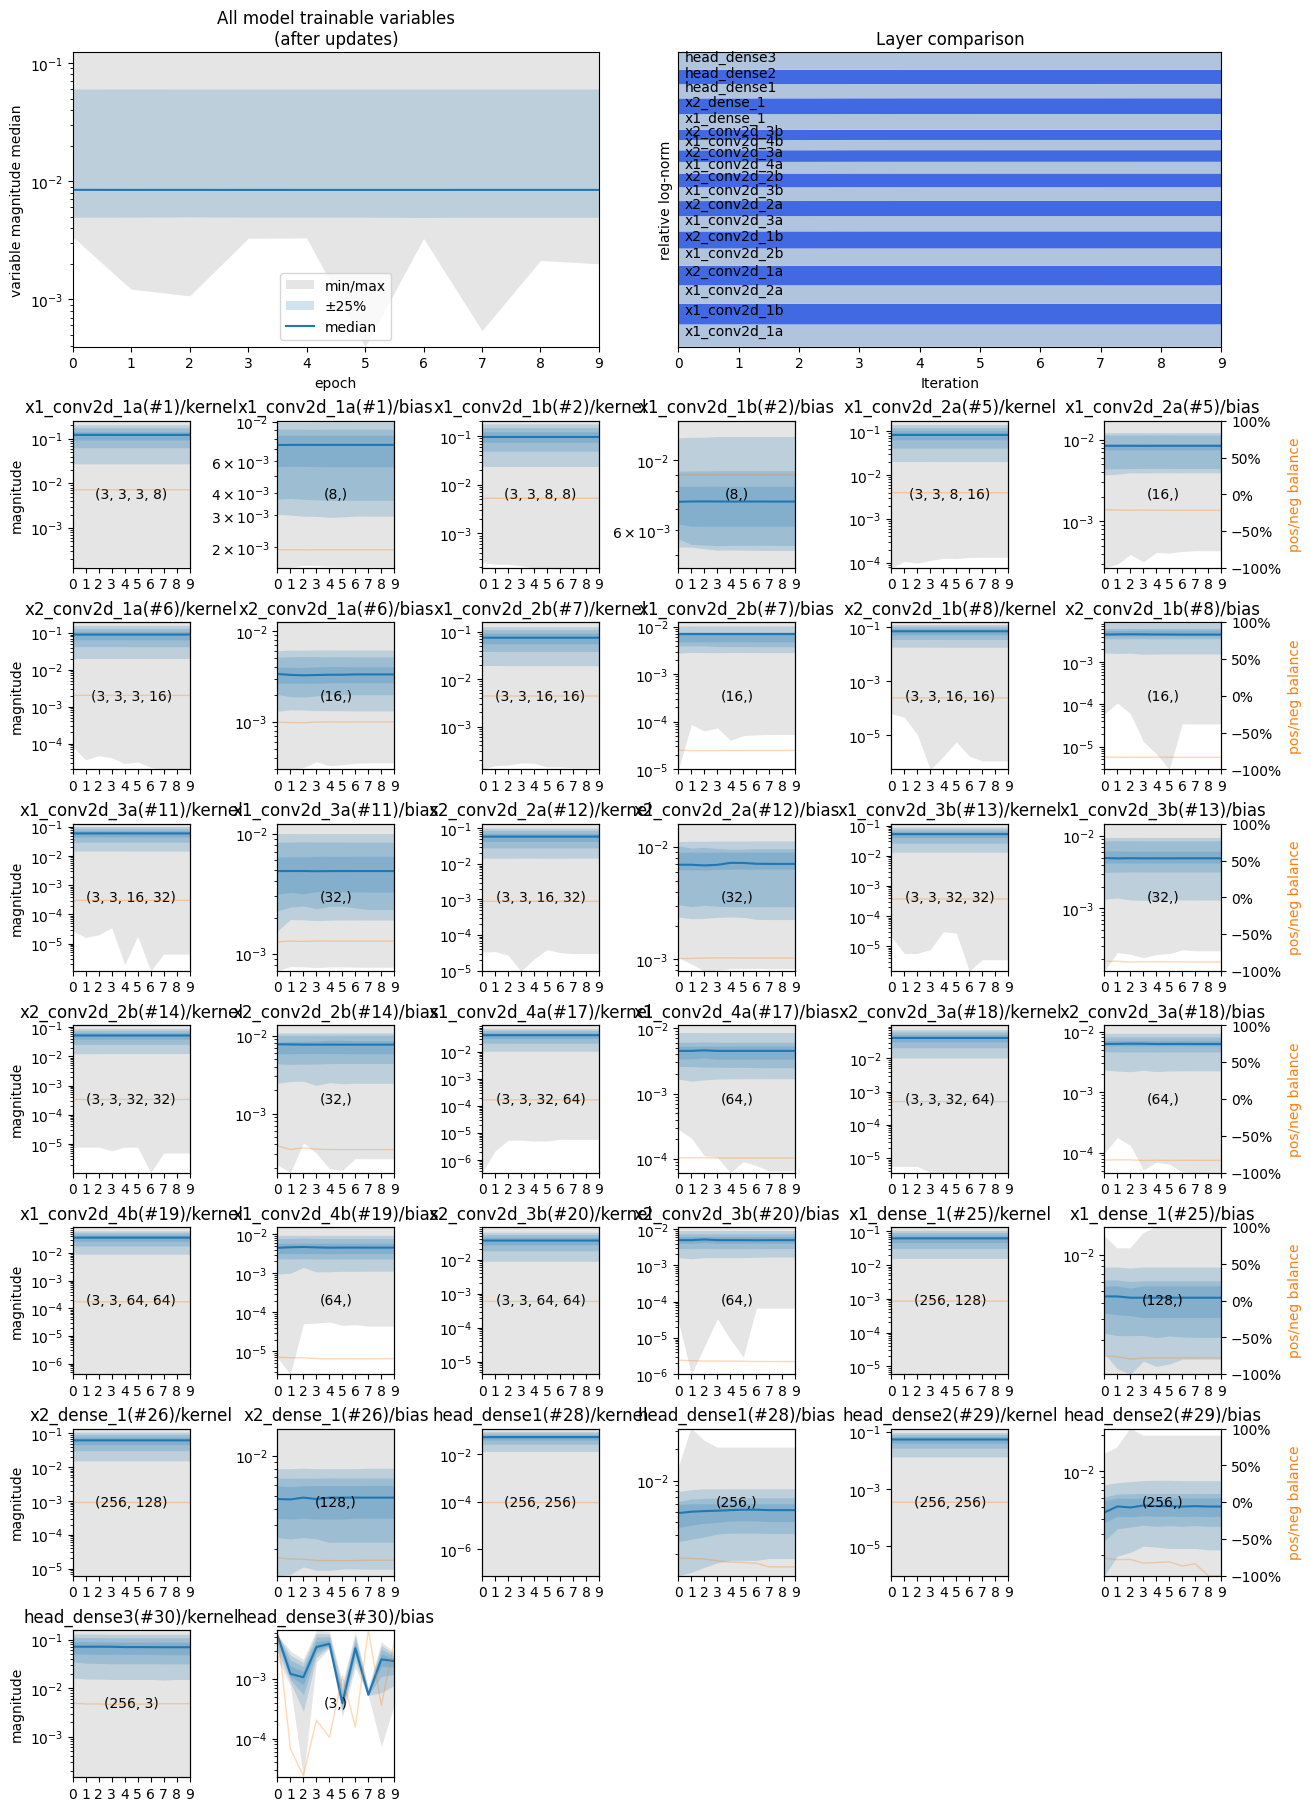

In [ ]:
tinstr.plot_value_history(variables)

**Commentary**

Apparently there's no problem with the weights themselves. The weights and biases all look very health (aside from the concerning level of stability).

## Detailed troubleshooting via 'train explainer'
We've identified that something's going on within the first epoch. Let's drill in closer by capturing data each step.

We'll also capture raw values so that we can use the [train explainer](https://github.com/malcolmlett/training-instrumentation-toolkit/blob/main/doc/train-explainer.ipynb) to automatically analyse the cause of neuron death. Capturing raw values can consume a lot of memory, so we need to identify up front which layers we'll apply that to. We'll focus on these layers:
* `[1]: x1_conv2d_1a  (input layer [0])`
* `[7]: x1_conv2d_2b  (input layer [5])`
* `[29]: head_dense2  (input layer [28])`

In total this requires us to capture the variables, gradients, outputs, and output gradients for all of those layers, plus the layer outputs for their input layers. The plot above is the easiest way of identifying these layers by number.

In [85]:
target_layer_idxs = [1, 7, 29]
input_layer_idxs = [0, 5, 28]

# use of before_updates=True, and batch_reduction=None needed for train_explainer to work correctly
variables = tinstr.VariableHistoryCallback(collection_sets=[{'layer_indices': target_layer_idxs}], before_updates=True, per_step=True)
gradients = tinstr.GradientHistoryCallback(collection_sets=[{'layer_indices': target_layer_idxs}], per_step=True)
outputs = tinstr.LayerOutputHistoryCallback(collection_sets=[{'layer_indices': input_layer_idxs}, {'layer_indices': target_layer_idxs}], batch_reduction=None, per_step=True)
output_gradients = tinstr.LayerOutputGradientHistoryCallback(collection_sets=[{'layer_indices': target_layer_idxs}], batch_reduction=None, per_step=True)

model = baseline_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32)
history = tinstr.fit(model, dataset, epochs=3, callbacks=[variables, gradients, outputs, output_gradients, tinstr.HistoryStats(per_step=True)])

Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 56s 251ms/step - loss: 0.0315
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - loss: 0.0315
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - loss: 0.0315


**Commentary**

First, let's review the overall training plots, and the activity rates of the gradients as before, but this time on a per-step basis...

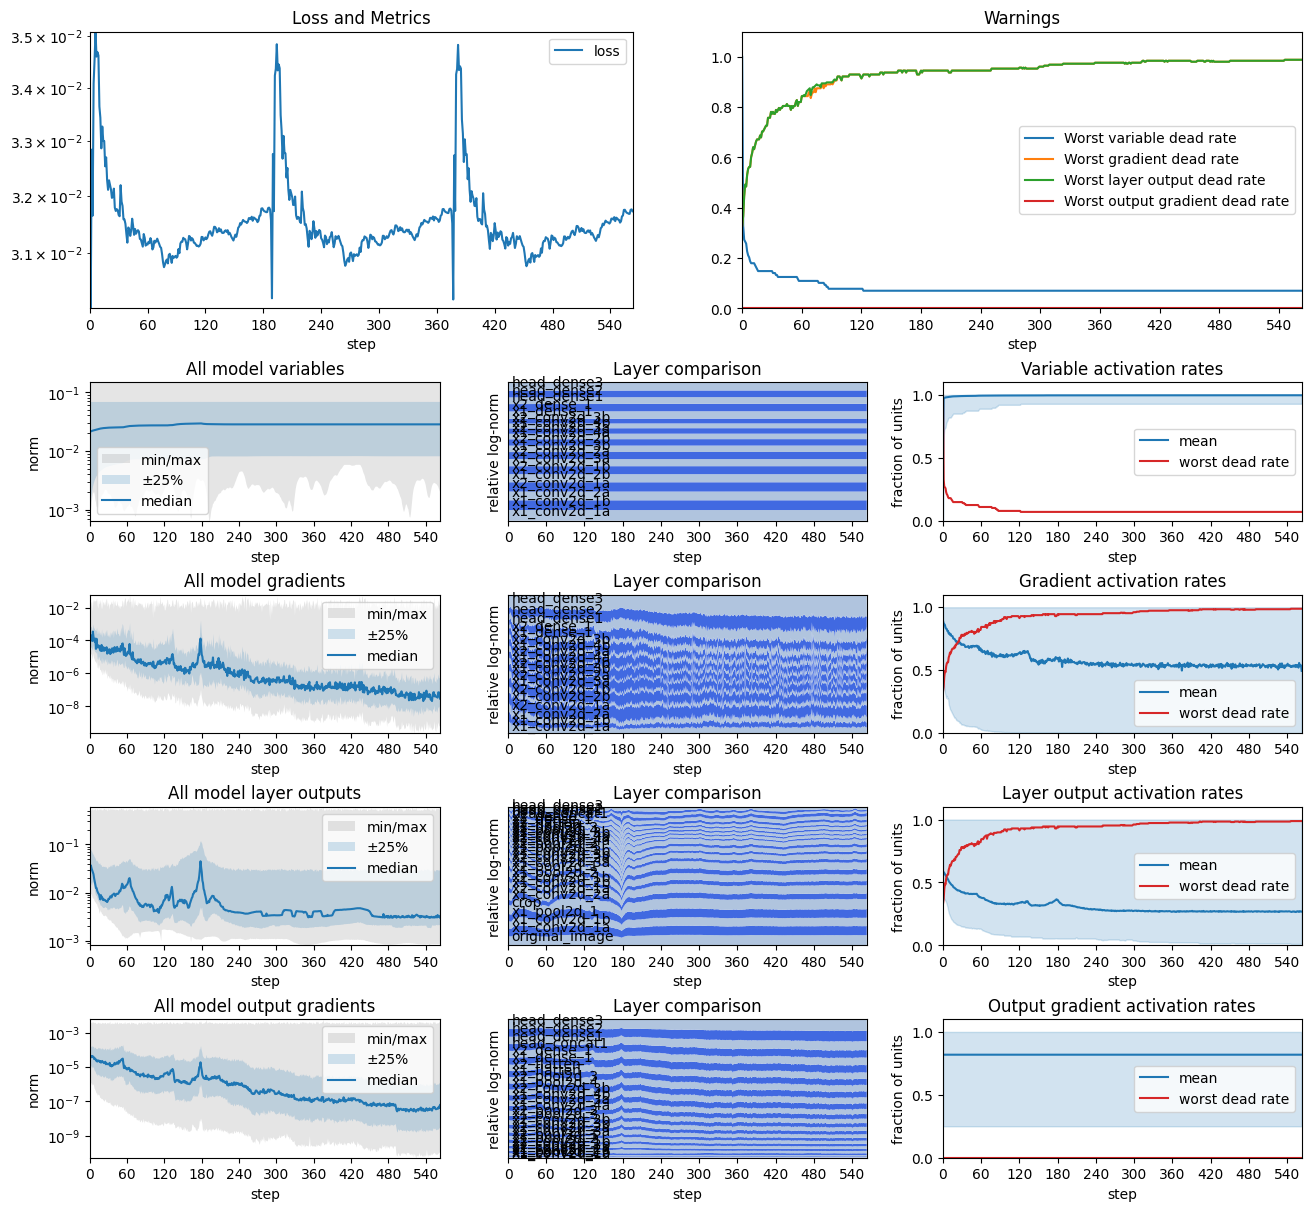

In [86]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

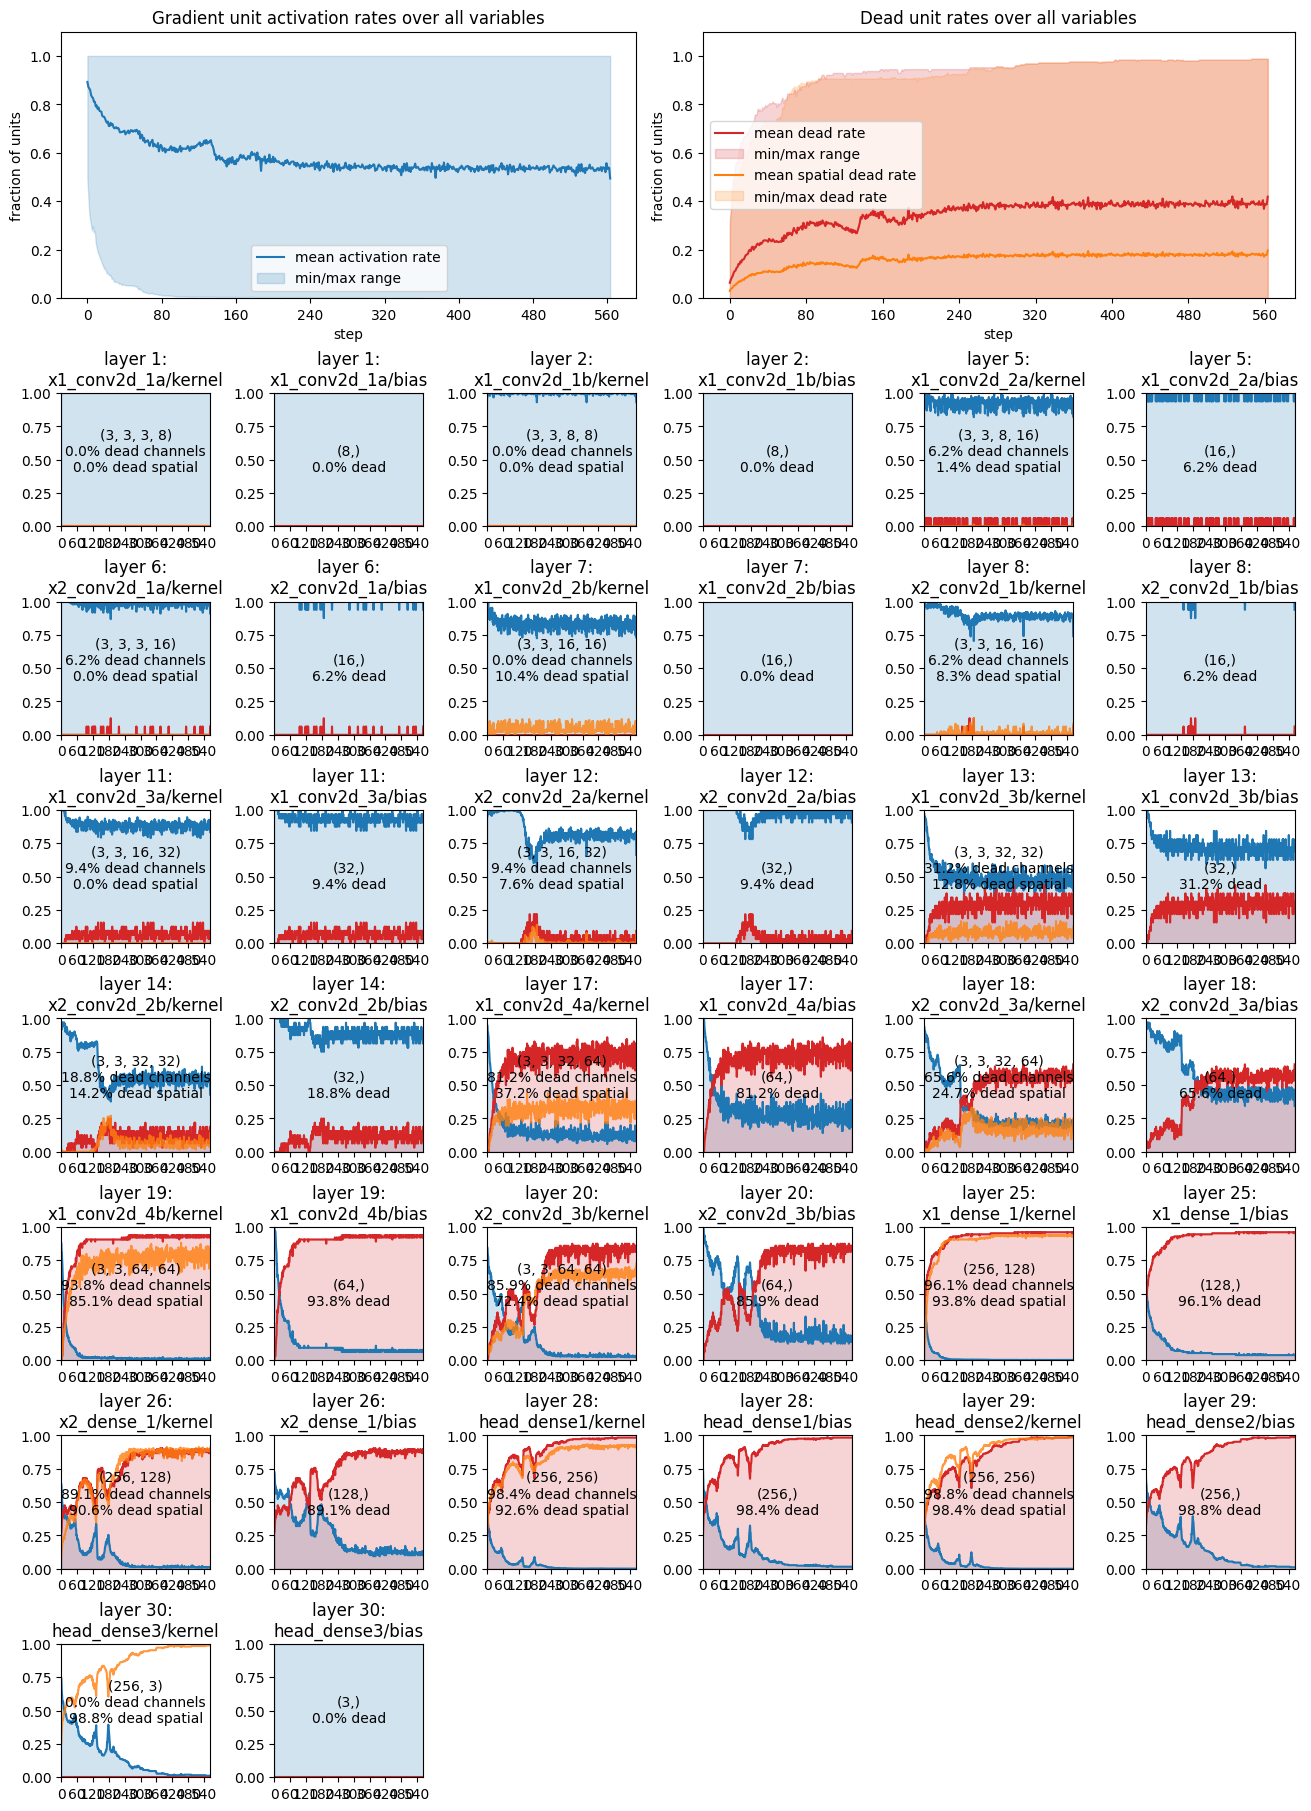

In [87]:
tinstr.plot_activity_history(gradients)

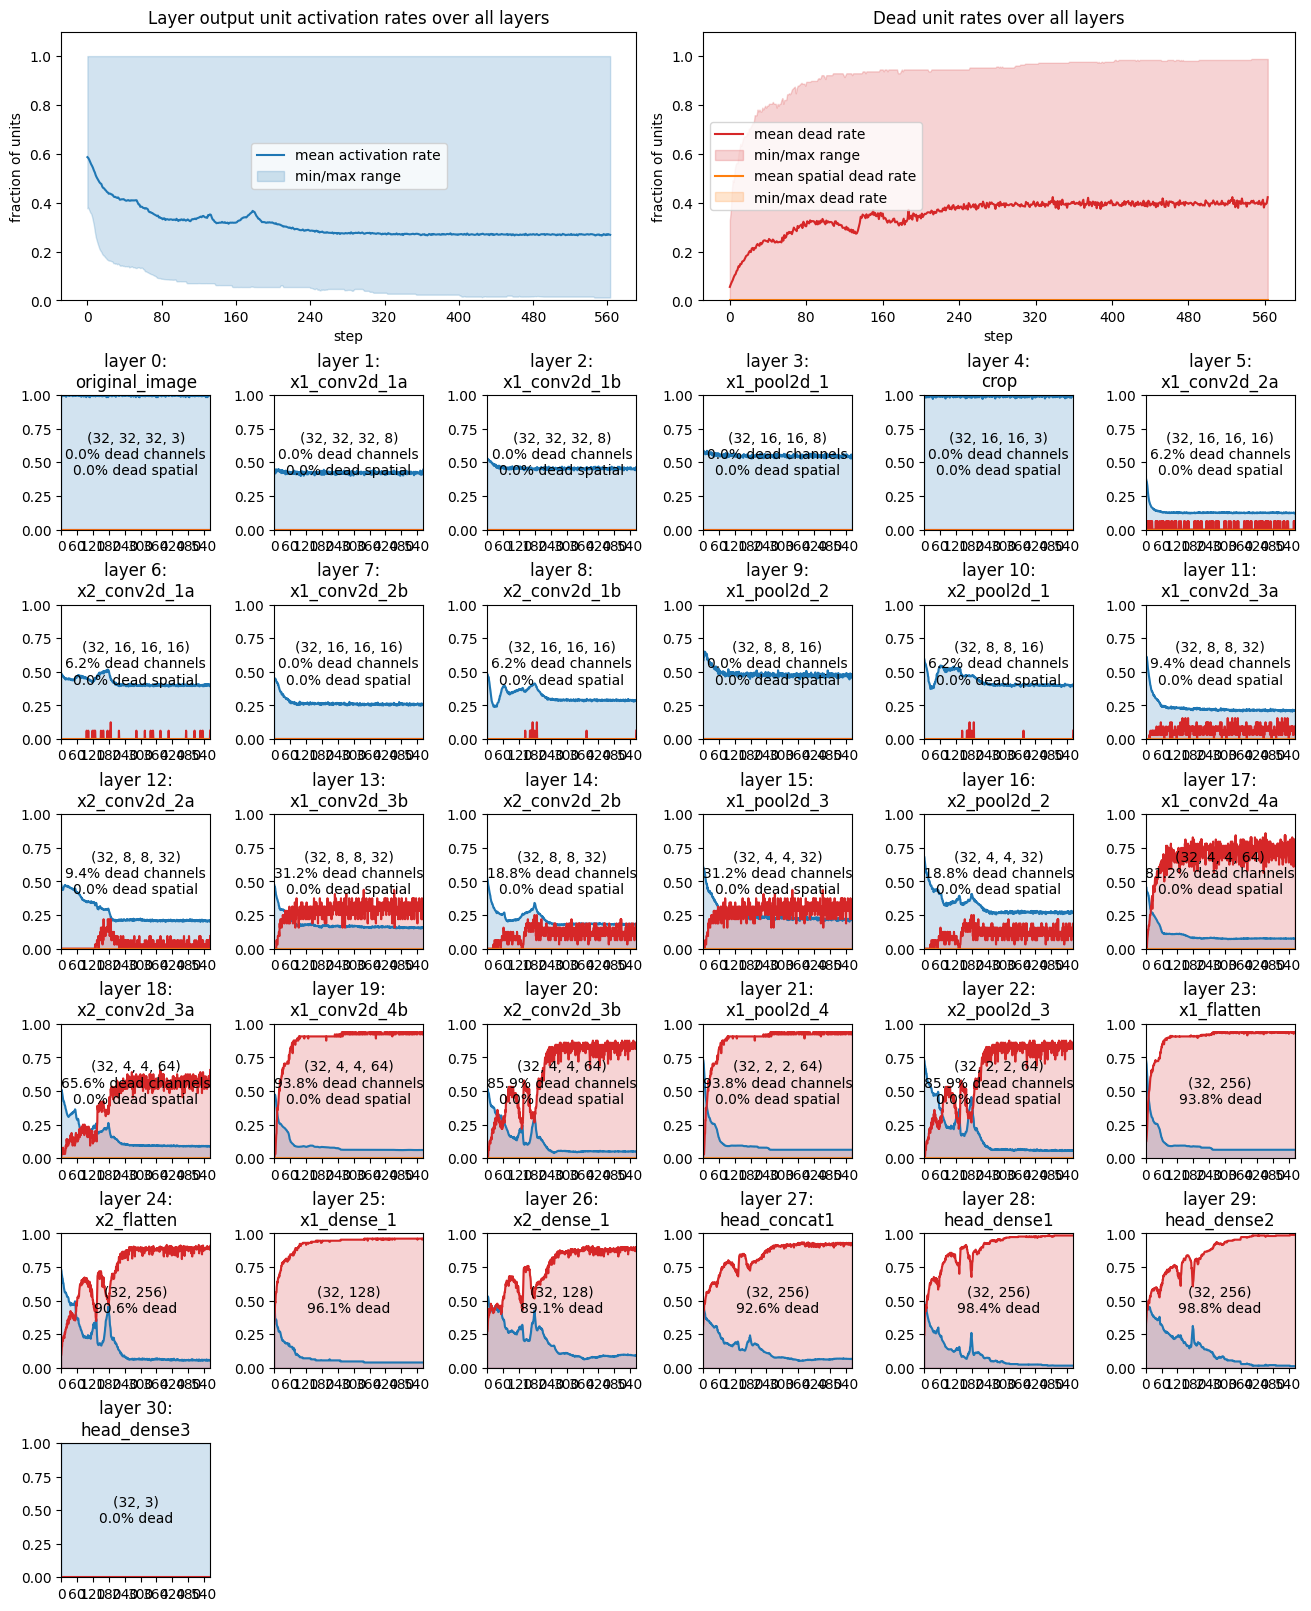

In [88]:
tinstr.plot_activity_history(outputs)

**Commentary**
* A brief word of warning: the above stats are collected _per-step_, meaning that they're only calculated on a single batch at a time, rather than the entire dataset. This means that low activity rates and neuron death will be a little exaggerated. But that's OK. We already know from the _per-epoch_ results that these values are indeed representative of the model behaviour across the whole training dataset.
* The final layer has 0% dead channels. That's not surprising given that it uses a linear activation function. But 99.2% of the inputs to the last layer are dead by the end of 3 epochs. The `head_dense2` layer outputs themselves are mostly all zeros, and this translates to mostly all zero gradients.
* Notice also that the activity rates of layer outputs gets very low across the board. Of particular concern is that this happens even in the earliest layers.


**Train Explainer**

We'll now use the [train explainer](https://github.com/malcolmlett/training-instrumentation-toolkit/blob/main/doc/train-explainer.ipynb) to automatically analyse some of these layers looking for causes of neuron death. It emulates some of the key calculations within the target layer, both in the forward and backward directions, and examines how the results of each calculation are affected by its different inputs. It sees _inside_ the workings of layer, and shows us what forces are at play to lead to neuron death.

If you haven't already, take a look at the notebook linked above for a detailed explanation of the 'train explainer' report.

To begin, let's look at the first conv layer on the x1 arm (`x1_conv2d_1a`). It seems to remain remarkably stagnant, so we'll generate a train explainer report for each of the first 3 training update steps.

In [89]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=1, step=0)

Examining layer #1 at iteration 0:
  layer:               x1_conv2d_1a
  units:               8
  weights:             216
  input from layers:   [0]
  output to layers:    [2]
  near-zero gradients: 3 (1.4%) < 2.5257151037294534e-08

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 32, 32, 3) -> total values: 98304
  summary:           0.9% near-zero
W_l - weights of target layer:
  shape:             (3, 3, 3, 8) -> total values: 216
  summary:           1.4% near-zero
  corresponding to near-zero gradients: 0.0% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 32, 32, 8) -> total values: 262144
  sum

In [90]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=1, step=1)

Examining layer #1 at iteration 1:
  layer:               x1_conv2d_1a
  units:               8
  weights:             216
  input from layers:   [0]
  output to layers:    [2]
  near-zero gradients: 3 (1.4%) < 6.397157648052598e-08

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 32, 32, 3) -> total values: 98304
  summary:           0.9% near-zero
W_l - weights of target layer:
  shape:             (3, 3, 3, 8) -> total values: 216
  summary:           1.4% near-zero
  corresponding to near-zero gradients: 0.0% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 32, 32, 8) -> total values: 262144
  summ

In [91]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=1, step=2)

Examining layer #1 at iteration 2:
  layer:               x1_conv2d_1a
  units:               8
  weights:             216
  input from layers:   [0]
  output to layers:    [2]
  near-zero gradients: 3 (1.4%) < 2.2515589392924085e-08

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 32, 32, 3) -> total values: 98304
  summary:           0.8% near-zero
W_l - weights of target layer:
  shape:             (3, 3, 3, 8) -> total values: 216
  summary:           1.4% near-zero
  corresponding to near-zero gradients: 0.0% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 32, 32, 8) -> total values: 262144
  sum

**Commentary**

_Note: the exact numbers below and in subsequent commentaries are taken from one particular run, and the notebook has likely been updated since then, but the overall trends should be about the same_

For layer `x1_conv2d_1a`, its pre-activation outputs are sitting pretty consistently around 39% negative (measured evenly across all dimensions in its 4-dim output tensor). Corresponding, this leads to about 39% of post-activation outputs as zero (ReLU activation).

> ```
> [step 0] Z_l - pre-activation output:
>   shape:             (32, 32, 32, 8) -> total values: 262144
>   summary:           39.6% negative
> [step 1] Z_l - pre-activation output:
>   shape:             (32, 32, 32, 8) -> total values: 262144
>   summary:           39.4% negative, 12.5% of units always near-zero or negative across all batch and spatial dims
> [step 2] Z_l - pre-activation output:
>   shape:             (32, 32, 32, 8) -> total values: 262144
>   summary:           39.2% negative
> ```

For a single batch, that's a little higher than we might like, but it's probably not too unreasonable. And it doesn't appear to be affecting the gradients too badly:

> ```
> [step 0] compute dJ/dW_l = A_0 conv^T dJ/dZ_l:
>   inputs examined:   A_0^T, dJ/dZ_l
>   summary:           1.4% near-zero, of which 99.9% are affected by near-zero values from dJ/dZ_l  
> [step 1] compute dJ/dW_l = A_0 conv^T dJ/dZ_l:
>   inputs examined:   A_0^T, dJ/dZ_l
>   summary:           12.5% near-zero, of which 100.0% are affected by near-zero values from dJ/dZ_l
> [step 2] compute dJ/dW_l = A_0 conv^T dJ/dZ_l:
>   inputs examined:   A_0^T, dJ/dZ_l
>   summary:           0.5% near-zero
> ```


Now let's go a little deeper into the network on the same x1 arm, looking instead at `x1_conv2d_2b`, layer 7...

In [92]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=7, step=0)

Examining layer #7 at iteration 0:
  layer:               x1_conv2d_2b
  units:               16
  weights:             2304
  input from layers:   [5]
  output to layers:    [9]
  near-zero gradients: 275 (11.9%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 16, 16, 16) -> total values: 131072
  summary:           62.3% near-zero, 6.2% of units always near-zero across all batch and spatial dims
W_l - weights of target layer:
  shape:             (3, 3, 16, 16) -> total values: 2304
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 0.7% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:  

In [93]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=7, step=1)

Examining layer #7 at iteration 1:
  layer:               x1_conv2d_2b
  units:               16
  weights:             2304
  input from layers:   [5]
  output to layers:    [9]
  near-zero gradients: 302 (13.1%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 16, 16, 16) -> total values: 131072
  summary:           62.1% near-zero, 6.2% of units always near-zero across all batch and spatial dims
W_l - weights of target layer:
  shape:             (3, 3, 16, 16) -> total values: 2304
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 0.3% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:  

In [94]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=7, step=2)

Examining layer #7 at iteration 2:
  layer:               x1_conv2d_2b
  units:               16
  weights:             2304
  input from layers:   [5]
  output to layers:    [9]
  near-zero gradients: 164 (7.1%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 16, 16, 16) -> total values: 131072
  summary:           63.1% near-zero
W_l - weights of target layer:
  shape:             (3, 3, 16, 16) -> total values: 2304
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 0.0% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 16, 16, 16) -> total values: 131072
  summary:     

In [95]:
# for comparison, last step in our 3-epoch training run
last_step = len(outputs.model_norm_stats)-1
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=7, step=last_step)

Examining layer #7 at iteration 563:
  layer:               x1_conv2d_2b
  units:               16
  weights:             2304
  input from layers:   [5]
  output to layers:    [9]
  near-zero gradients: 619 (26.9%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (16, 16, 16, 16) -> total values: 65536
  summary:           88.0% near-zero, 6.2% of units always near-zero across all batch and spatial dims
W_l - weights of target layer:
  shape:             (3, 3, 16, 16) -> total values: 2304
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 1.3% near-zero
compute Z_l = A_0 conv W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape: 

In [96]:
# Finally, we'll also print the verbose report on the last step
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=7, step=last_step, verbose=True)

Examining layer #7 at iteration 563:
  layer:               x1_conv2d_2b
  units:               16
  weights:             2304
  input from layers:   [5]
  output to layers:    [9]
  near-zero gradients: 619 (26.9%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer
  PZN      <- breakdown of values into (P)ositive, near-(Z)ero, or (N)egative
  x . y    <- matmul (aka dot product)
  x (.) y  <- element-wise multiply

Forward pass...
A_0 - input value:
  shape:             (16, 16, 16, 16) -> total values: 65536
  summary:           88.0% near-zero (= 0), 6.2% of units always near-zero across all batch and spatial dims
  value percentiles: [0, 25, 50, 75, 100] -> [0.         0.         0.         0.         0.26987293]
  PZN counts/sums:   Z: 57643.0 = Σ 0.0, P: 7893.0 = Σ 28

**Commentary**

Based on the plots alone, `x1_conv2d_1a` and `x1_conv2d_2b` look to be fairly similar. But once we analyse deeper, we can see that `x1_conv2d_2b` has more fascinating story to tell...which I'll examine in three parts.

Inputs to x1_conv2d_2b:

> ```
> A_0 - input value:
>   shape:             (32, 16, 16, 16) -> total values: 131072
>   [step 0]   summary:  66.7% near-zero, 6.2% of units always near-zero across all batch and spatial dims
>   [step 1]   summary:  66.5% near-zero, 6.2% of units always near-zero across all batch and spatial dims
>   [step 2]   summary:  65.5% near-zero
>   [step 563] summary:  68.3% near-zero, 6.2% of units always near-zero across all batch and spatial dims
> ```

* The input to this layer remains consistently at around 67% near-zero, from the very first step through to the last step (3 epochs).
* We know that the model enters high neuron death within the first epoch, but it can't do that during the very first step before any updates have been applied. So it seems that the inputs to this layer are not the cause of the problem.

Pre-activation output:

> ```
> Z_l - pre-activation output:
>   shape:             (32, 16, 16, 16) -> total values: 131072
>   [step 0]   summary:  46.7% negative
>   [step 1]   summary:  47.6% negative
>   [step 2]   summary:  49.7% negative
>   [step 563] summary:  73.7% negative
> ```

* The pre-activation outputs from this layer start at 47% but steadily increase, reaching 74% after 3 epochs.
* It looks like this layer is being pushed towards neuron death.

Backprop:

> ```
> dJ/dA_l - backprop into this layer:
>   shape:               (32, 16, 16, 16) -> total values: 131072
>   [step 0]   summary:  75.0% near-zero
>   [step 1]   summary:  75.0% near-zero
>   [step 2]   summary:  75.0% near-zero
>   [step 563] summary:  75.0% near-zero
> compute dJ/dZ_l = dJdA_l (.) S_l:
>   inputs examined:     dJ/dA_l, S_l
>   shape:               (32, 16, 16, 16) -> total values: 131072
>   [step 0]   summary:  84.0% near-zero, of which 89.3% are affected by near-zero values from dJ/dA_l
>   [step 1]   summary:  84.1% near-zero, of which 89.2% are affected by near-zero values from dJ/dA_l
>   [step 2]   summary:  84.4% near-zero, of which 88.9% are affected by near-zero values from dJ/dA_l
>   [step 563] summary:  90.4% near-zero, of which 82.9% are affected by near-zero values from dJ/dA_l
>                        (and 81.5% affected by near-zero values from S_l)
> compute dJ/dW_l = A_0 conv^T dJ/dZ_l:
>   inputs examined:     A_0^T, dJ/dZ_l
>   shape:               (3, 3, 16, 16) -> total values: 2304
>   [step 0]   summary:  19.2% near-zero, of which 98.8% are affected by near-zero values from A_0^T
>   [step 1]   summary:  19.5% near-zero, of which 97.3% are affected by near-zero values from A_0^T
>   [step 2]   summary:   8.6% near-zero, of which 99.7% are affected by near-zero values from A_0^T
>   [step 563] summary:  33.6% near-zero, of which 98.4% are affected by near-zero values from A_0^T
>                        (and 92.7% affected by near-zero values from dJ/dZ_l)
> ```

* There's a consistent 75% near-zero rate for $\frac{\partial J}{\partial A_l}$, the gradients back-propagated from the next layer to this. That's a high percentage. It'll mean that there's a weak training signal reaching this layer, but it won't cause it to produce negative pre-activation outputs.
* Within a single layer, there are two steps to calculating the gradients for its weights. You first need to compute $\frac{\partial J}{\partial Z_l}$, the gradients w.r.t to the layer's pre-activation output. This is computed by element-wise multiplication between the backprop'ed $\frac{\partial J}{\partial A_l}$, and the "effect" of the layer's activation function. Because our layer uses ReLU, this effect is just a matrix of 1s and 0s depending on whether the output was passed through unchanged or zeroed out by ReLU. This calculation results in 85+% near-zero values. You have to view the report in verbose mode to see the full details, but it turns out that this is caused almost equally by the near-zeros coming from the back-prop gradients and from the layer's own outputs.
* The final calculation of weight gradients takes both the above calculated $\frac{\partial J}{\partial Z_l}$ and the layer's input $A_{l-1}$ (indicated as `A_0` in the report because it's hard to represent $A_{l-1}$ in ASCII). Both of those inputs have a high percentage of near-zeros, and they're both contributing to the near-zeros in the final weight gradients.
* It's instructive to note that the weight gradients suffer from near-zeros much less so than their inputs. This is a result of the way that matrix multiplication works, summing across corresponding rows and columns of the input matrices, effectively averaging or smoothing out the presence of single-element zeros by the presence of non-zeros found elsewhere. This is why it's possible for a network to continue to train in the presence of neuron death, and even to recover neurons that had been dead before.

In all, this layer suffers from near-zeros in all directions: i) from its inputs, ii) from the backprop gradients, and iii) from its own output (due to negative pre-activation outputs). This layer is probably the victim, not the contributing cause.

Now let's jump to the end of the network and look at `head_dense2` (layer 29). We'll again generate reports for the first 3 steps, and for the very last step of the 3-epoch training run...

In [97]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=29, step=0)

Examining layer #29 at iteration 0:
  layer:               head_dense2
  units:               256
  weights:             65536
  input from layers:   [28]
  output to layers:    [30]
  near-zero gradients: 31269 (47.7%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 256) -> total values: 8192
  summary:           51.3% near-zero, 24.6% of units always near-zero across all batch dims
W_l - weights of target layer:
  shape:             (256, 256) -> total values: 65536
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 1.0% near-zero
compute Z_l = A_0 . W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 256)

In [98]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=29, step=1)

Examining layer #29 at iteration 1:
  layer:               head_dense2
  units:               256
  weights:             65536
  input from layers:   [28]
  output to layers:    [30]
  near-zero gradients: 37572 (57.3%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 256) -> total values: 8192
  summary:           52.7% near-zero, 34.0% of units always near-zero across all batch dims
W_l - weights of target layer:
  shape:             (256, 256) -> total values: 65536
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 1.0% near-zero
compute Z_l = A_0 . W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 256)

In [99]:
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=29, step=2)

Examining layer #29 at iteration 2:
  layer:               head_dense2
  units:               256
  weights:             65536
  input from layers:   [28]
  output to layers:    [30]
  near-zero gradients: 41028 (62.6%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (32, 256) -> total values: 8192
  summary:           54.5% near-zero, 39.8% of units always near-zero across all batch dims
W_l - weights of target layer:
  shape:             (256, 256) -> total values: 65536
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 1.0% near-zero
compute Z_l = A_0 . W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (32, 256)

In [100]:
last_step = len(outputs.model_norm_stats)-1
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=29, step=last_step)

Examining layer #29 at iteration 563:
  layer:               head_dense2
  units:               256
  weights:             65536
  input from layers:   [28]
  output to layers:    [30]
  near-zero gradients: 65524 (100.0%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer

Forward pass...
A_0 - input value:
  shape:             (16, 256) -> total values: 4096
  summary:           98.4% near-zero, 98.4% of units always near-zero across all batch dims
W_l - weights of target layer:
  shape:             (256, 256) -> total values: 65536
  summary:           1.0% near-zero
  corresponding to near-zero gradients: 1.0% near-zero
compute Z_l = A_0 . W_l + b_l:
  inputs examined:   A_0, W_l
  summary:           1.0% near-zero
Z_l - pre-activation output:
  shape:             (16, 2

In [101]:
# and in verbose mode...
last_step = len(outputs.model_norm_stats)-1
texpl.explain_near_zero_gradients([variables, gradients, outputs, output_gradients], layer_index=29, step=last_step, verbose=True)

Examining layer #29 at iteration 563:
  layer:               head_dense2
  units:               256
  weights:             65536
  input from layers:   [28]
  output to layers:    [30]
  near-zero gradients: 65524 (100.0%) = 0

Let:
  A_0      <- input activation to target layer
  W_l      <- weights of target layer
  Z_l      <- pre-activation output of target layer
  S_l      <- effect of activation function as element-wise multiplier
  A_l      <- output activation of target layer
  PZN      <- breakdown of values into (P)ositive, near-(Z)ero, or (N)egative
  x . y    <- matmul (aka dot product)
  x (.) y  <- element-wise multiply

Forward pass...
A_0 - input value:
  shape:             (16, 256) -> total values: 4096
  summary:           98.4% near-zero (= 0), 98.4% of units always near-zero across all batch dims
  value percentiles: [0, 25, 50, 75, 100] -> [0.         0.         0.         0.         0.01369155]
  PZN counts/sums:   Z: 4032.0 = Σ 0.000000, P: 64.0 = Σ 0.644935
  P

**Commentary**

Here we're seeing a very different behaviour to the earlier layers. Let's examine it in the same way we did for the previous layer...

Inputs:

> ```
> A_0 - input value:
>   shape:              (32, 256) -> total values: 8192
>   [step 0]   summary: 51.3% near-zero, 24.6% of units always near-zero across all batch dims
>   [step 1]   summary: 52.7% near-zero, 34.0% of units always near-zero across all batch dims
>   [step 2]   summary: 54.5% near-zero, 39.8% of units always near-zero across all batch dims
>   [step 563] summary: 98.4% near-zero, 98.4% of units always near-zero across all batch dims
> ```

* The inputs to this layer start off fairly bad even on step 0, before any updates have been applied to any layers, but they get steadily worse.
* The total near-zero percentage (across all tensor elements, regardless of meaning) is a clear omen for unit death (given output unit is zero for all samples in the batch).

Pre-activation outputs:

> ```
> Z_l - pre-activation output:
>   shape:              (32, 256) -> total values: 8192
>   [step 0]   summary: 48.8% negative, 26.2% of units always near-zero or negative across all batch dims
>   [step 1]   summary: 48.8% negative, 32.8% of units always near-zero or negative across all batch dims
>   [step 2]   summary: 51.1% negative, 35.5% of units always near-zero or negative across all batch dims
>   [step 563] summary: 98.8% negative, 98.8% of units always near-zero or negative across all batch dims
> ```

* The pre-activation outputs get increasingly negative. That's why we're getting neuron death.
* Notice that the rate of negative pre-activation outputs mirrors that of near-zero inputs. One possibility is that  the few remaining weights that correlate with non-zero inputs are negative - ie: the input is being modified by SGD to favour negative weights.
* The verbose report gives us the answer by grouping the outputs into whether each of the inputs is respectively positive (P), negative (N), or near-zero (Z). Listing that off organised by A_0 classification we have the following:

```
  P-input: PN: 8544.0 = Σ -4.955, PP: 7712.0 = Σ 4.165, PZ: 128.0 = Σ 0.000
  Z-input: ZN: 517488.0 = Σ 0.000, ZP: 504336.0 = Σ 0.000, ZZ: 10368.0 = Σ 0.000
  N-input: nil.
```

* In other words, we've got a lot of zero inputs that result in zeroes in the computed Z value. Not surprising given 98.4% near-zeros in the input.
* Of those inputs that are non-zero, on first glance there's a pretty good parity between positive and negative outcome...but there is in fact a bias towards negative weights (52.1% vs 47.1% of those multiplications with positive input elements) with an ultimate bias in the result.

Backprop:

> ```
> dJ/dA_l - backprop into this layer:
>   shape:              (32, 256) -> total values: 8192
>   [step 0]   summary: 1.0% near-zero
>   [step 1]   summary: 1.0% near-zero
>   [step 2]   summary: 1.0% near-zero
>   [step 563] summary: 1.0% near-zero
>     PZN counts/sums:   N: 2044.0 = Σ -1.312, P: 2011.0 = Σ 1.302, Z: 41.0 = Σ -0.000
>     PZN counts/means:  N: 49.9% x -0.000642036, P: 49.1% x 0.000647539, Z: 1.0% x -0.000001471
> ```

* The backprop from the last layer contains a reasonable percentage of near-zeros. In fact, the train-explainer applies heuristics to determine what it classifies as "near-zero", and one of its key heuristics is to pick the bottom 1-percentile. Thus it's default is to find exactly 1% of near-zeros.
* Furthermore, the rest of the backprop values are quite evenly split between negative and positive values. Thus all suggests that our loss function may be behaving correctly.

> ```
> compute dJ/dZ_l = dJdA_l (.) S_l:
>   inputs examined:    dJ/dA_l, S_l
>   shape:              (32, 256) -> total values: 8192
>   [step 0]   summary: 48.8% near-zero, of which 100.0% are affected by near-zero values from S_l
>   [step 1]   summary: 48.8% near-zero, of which 100.0% are affected by near-zero values from S_l
>   [step 2]   summary: 51.1% near-zero, of which 100.0% are affected by near-zero values from S_l
>   [step 563] summary: 98.8% near-zero, of which 100.0% are affected by near-zero values from S_l
>                       and 5.0% affected by near-zero values from dJ/dA_l
> ```

* Gradients flowing through the layer have rapidly progressed towards a high near-zero count.
* Note that this is almost entirely due to the layer's own output, rather than from the backprop gradients coming into the layer.

> ```
> compute dJ/dW_l = A_0^T . dJ/dZ_l:
>   inputs examined:    A_0^T, dJ/dZ_l
>   shape:              (256, 256) -> total values: 65536
>   [step 0]   summary: 47.7% near-zero, of which 72.5% are affected by near-zero values from A_0^T
>   [step 1]   summary: 57.3% near-zero, of which 72.5% are affected by near-zero values from A_0^T
>   [step 2]   summary: 62.6% near-zero, of which 73.8% are affected by near-zero values from A_0^T
>   [step 563] summary: 100.0% near-zero, of which 98.8% are affected by near-zero values from dJ/dZ_l
>                       and 98.5% affected by near-zero values from A_0^T
```

* Likewise, the final computed weight gradients quickly grow in the rate of near-zero values, and by the 3rd epoch we have 100% near-zero (for a single batch) and thus with a high neuron death.
* Notice that this outcome is an equally shared result of $A_{l-1}$ and $\frac{\partial J}{\partial Z_l}$. However, also note that $\frac{\partial J}{\partial Z_l}$ is primarily influenced by $S_l$, in terms of near-zero results, which itself is primarily influenced by $A_{l-1}$.


## Theory
We've identified that we're getting neuron death because pre-activation outputs are somehow being pushed towards negative. But _why_?

At this point I'd like to be able to say that there's a method for investigating exactly that 'why'. Unfortunately I can't. I've tried a few approaches but so far haven't found a way to get a good clear signal of the cause. The problem is that most of the components involved (gradients, outputs, etc.) still have a fairly even distribution between negative and positive values. Furthermore, if you ignore the percentage of zeros, the shape of the distributions in the above training run look very similar to distributions in successful training runs on more successful models. I suspect that the trick lies in finding correlations between problematic layer outputs, the weights, and the gradients.

Without that most direct approach, the next best thing is to develop some theories that might explain the behaviour. That will guide our attempts to find a solution.



Before proceeding, it's a good idea to develop some theories of why this might be occurring...


## (Misplaced)

**Final state Activity Plots**

For some further insight, we can also plot a more detailed histogram of the activation values at each layer when running the trained model against the whole dataset. In practice I usually find this less insightful than the graphs above, but it can help to understand what's going on by seeing the same thing from another perspective.

In [ ]:
_, _, layer_channel_activity, layer_spatial_activity = tinstr.measure_unit_activity(model, dataset, include_channel_activity=True, include_spatial_activity=True)

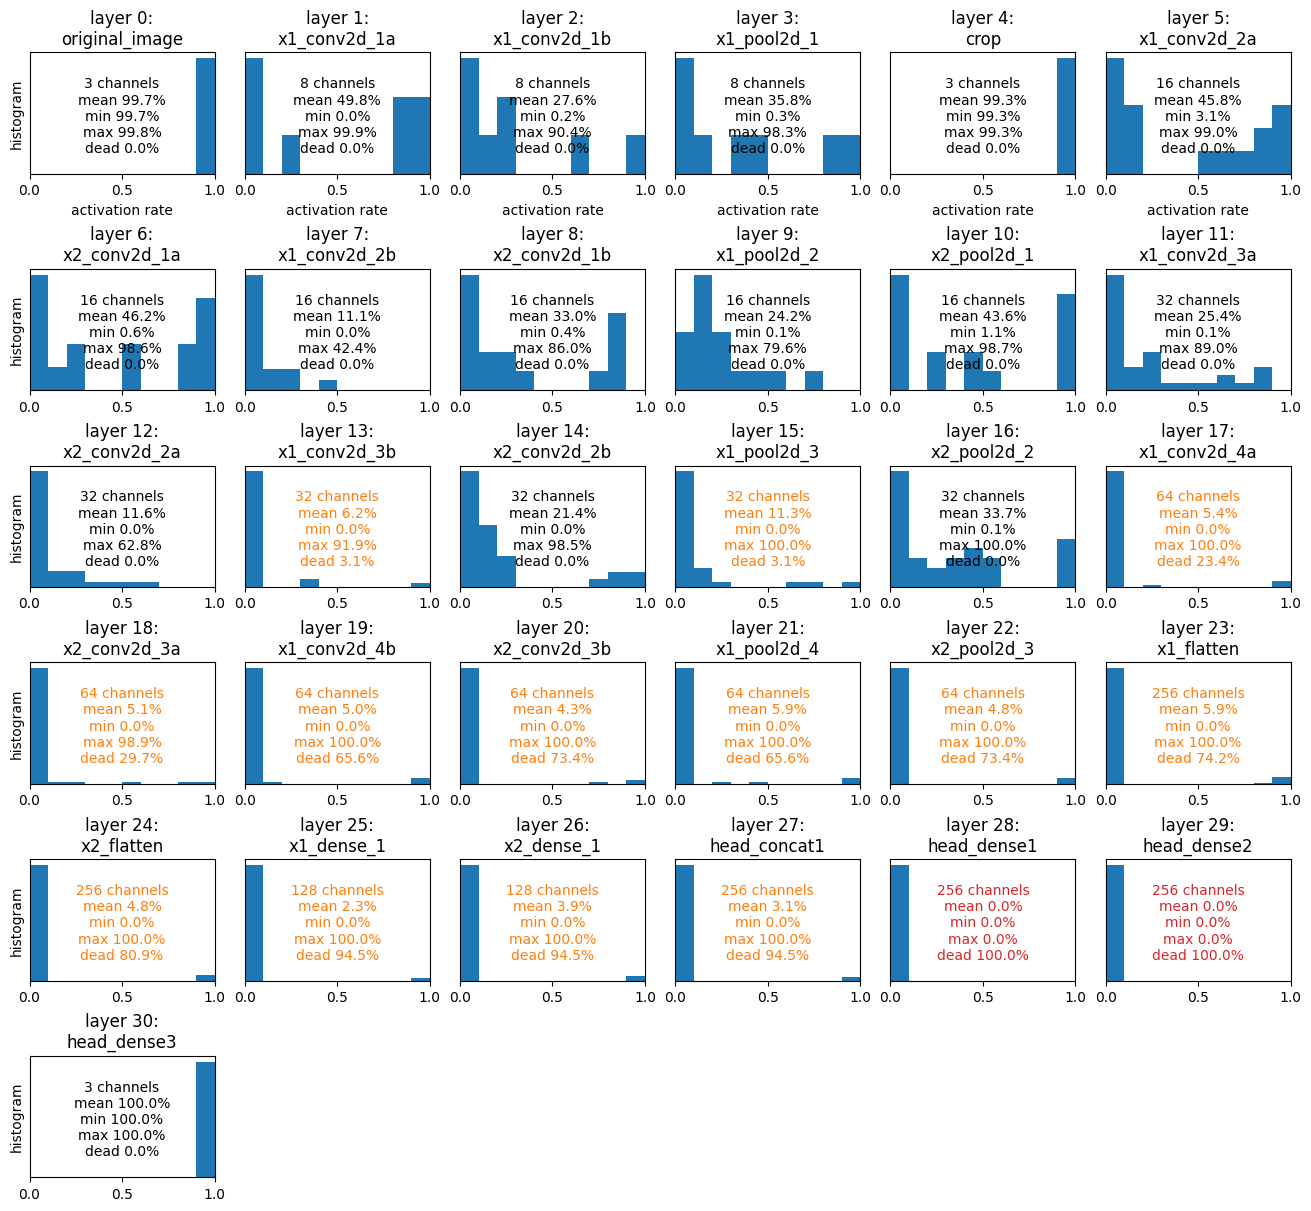

In [ ]:
tinstr.plot_channel_stats(layer_channel_activity, model)

And the following looks at the same thing but from the point of view of the spatial coordinates...

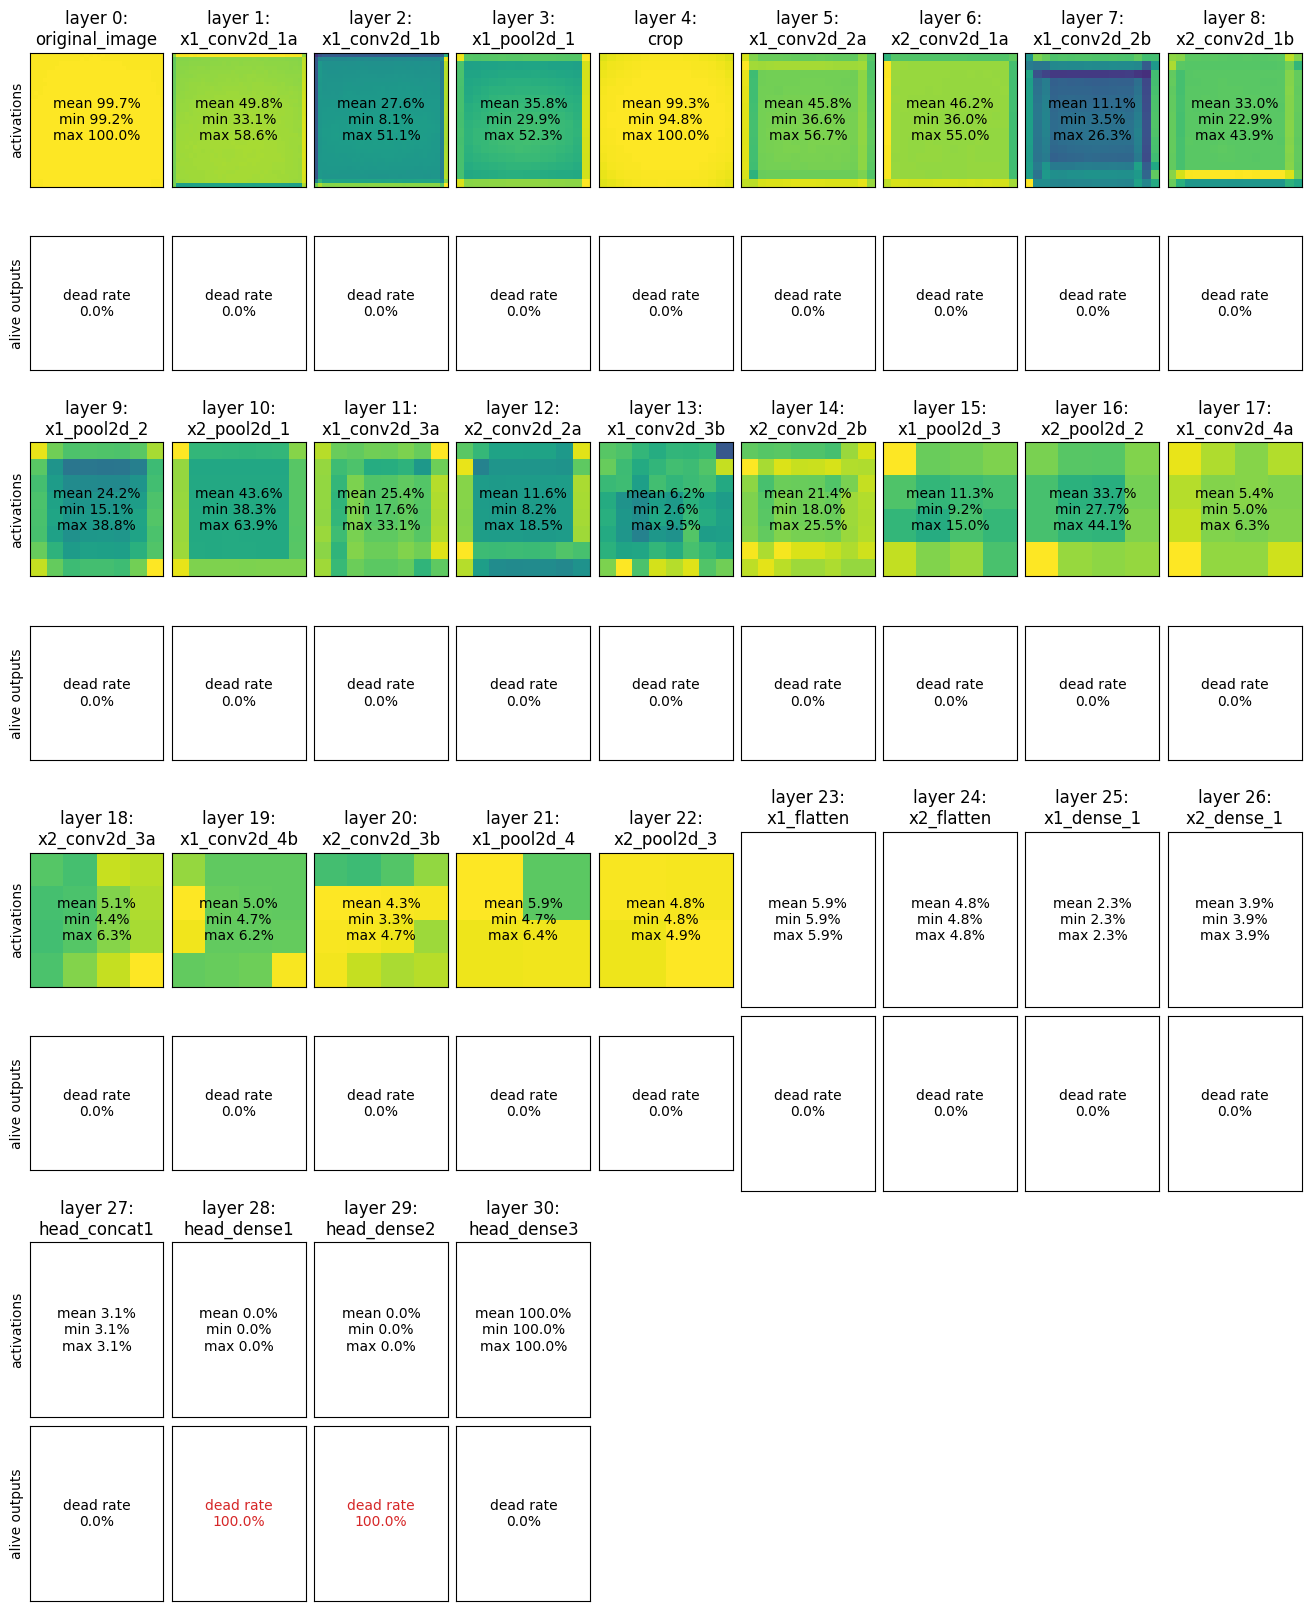

In [ ]:
tinstr.plot_spatial_stats(layer_spatial_activity, model)

## Solution 1 - Cross-Attention
We'll size this revised model so that it has approximately similar numbers.

In [ ]:
def position_encoding(height, width, dim):
    def sincos_1d(num_positions, d_model):
        # Standard sinusoidal encoding for a 1D sequence
        # shape => (num_positions, d_model)
        position = np.arange(num_positions)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((num_positions, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        return pe

    # Half of the channels encode the row, half the column
    row_pe = sincos_1d(height, dim // 2)  # (height, dim//2)
    col_pe = sincos_1d(width, dim // 2)   # (width,  dim//2)

    # Build a 2D position encoding by combining row & column
    pos_encoding_2d = np.zeros((height, width, dim))
    for r in range(height):
        for c in range(width):
            pos_encoding_2d[r, c, :dim // 2] = row_pe[r]
            pos_encoding_2d[r, c, dim // 2:] = col_pe[c]

    # Flatten to (height*width, dim)
    pos_encoding = pos_encoding_2d.reshape((height * width, dim))
    return tf.constant(pos_encoding, dtype=tf.float32)

def cross_attention_conv_model():
    original_input = tf.keras.Input(shape=(32, 32, 3), name="original_image")
    crop_input = tf.keras.Input(shape=(16, 16, 3), name="crop")

    # A CNN stack for the 32x32 original image
    # - 32x32x3 -> 16x16x8 -> 8x8x16 -> 64x16
    x1 = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1a')(original_input)
    x1 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_1')(x1)
    x1 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2a')(x1)
    x1 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_2')(x1)
    x1 = layers.Reshape((-1, 64), name='x1_reshape')(x1)

    # Separate CNN stack for the 16x16 cropped input
    # - 16x16x3 -> 8x8x16 -> 64x16
    x2 = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1b')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_1')(x2)
    x2 = layers.Reshape((-1, 64), name='x2_reshape')(x2)

    # Add positional encodings for an 8×8 grid
    pos_emb_8x8 = position_encoding(8, 8, 64)
    x1 = x1 + pos_emb_8x8
    x2 = x2 + pos_emb_8x8

    # Cross self-attention
    # - technically this is "joint self-attention"
    x = layers.Concatenate(axis=1, name='head_concat1')([x1, x2])
    x = layers.Dense(256, activation='relu', name='head_dense1')(x)
    x_attn = layers.MultiHeadAttention(num_heads=4, key_dim=16, name='head_mhe1')(x, x)
    x_attn = layers.LayerNormalization(name='head_norm1')(x_attn + x)
    x_ff = layers.Dense(256, activation='relu', name='head_dense2')(x_attn)
    print(f"x_attn: {x_attn.shape}")
    x = layers.LayerNormalization(name='head_norm2')(x_attn + x_ff)

    # Final regression head
    # - 64x256 -> 256 -> 3 (dx, dy, da)
    x = layers.GlobalAveragePooling1D(name='head_pool1')(x)
    x = layers.Dense(256, activation='relu', name='head_dense3')(x)
    x = layers.Dense(256, activation='relu', name='head_dense4')(x)
    out = layers.Dense(3, activation='linear', name='head_dense5')(x)

    return tf.keras.Model(inputs=[original_input, crop_input], outputs=out)

# Uncomment if you just want to see the model summary
cross_attention_conv_model().summary()

x_attn: (None, 128, 256)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ original_image            │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1a (Conv2D)     │ (None, 32, 32, 8)      │            224 │ original_image[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1b (Conv2D)     │ (None, 32, 32, 16)     │          1,168 │ x1_conv2d_1a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_1               │ (None, 16, 16, 16)     │              0 │ x1_conv2d_1b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ crop (InputLayer)         │ (None, 16, 16, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2a (Conv2D)     │ (None, 16, 16, 32)     │          4,640 │ x1_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1a (Conv2D)     │ (None, 16, 16, 32)     │            896 │ crop[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2b (Conv2D)     │ (None, 16, 16, 64)     │         18,496 │ x1_conv2d_2a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1b (Conv2D)     │ (None, 16, 16, 64)     │         18,496 │ x2_conv2d_1a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_2               │ (None, 8, 8, 64)       │              0 │ x1_conv2d_2b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_pool2d_1               │ (None, 8, 8, 64)       │              0 │ x2_conv2d_1b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_reshape (Reshape)      │ (None, 64, 64)         │              0 │ x1_pool2d_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_reshape (Reshape)      │ (None, 64, 64)         │              0 │ x2_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 64, 64)         │              0 │ x1_reshape[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 64, 64)         │              0 │ x2_reshape[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ head_concat1              │ (None, 128, 64)        │              0 │ add[0][0], add_1[0][0] │
│ (Concatenate)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ head_dense1 (Dense)       │ (None, 128, 256)       │         16,640 │ head_concat1[0][0]     │
├──────────────────────

 Total params: 325,715 (1.24 MB)

 Trainable params: 325,715 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = cross_attention_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=50, callbacks=[tinstr.HistoryStats()])

x_attn: (None, 128, 256)
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0931
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0347
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0315
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0312
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0306
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0306
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0330
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0311
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0310
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0308
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0314
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0303
Epoch 13/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0305
Epoch 14/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0319
Epoch 15/50
188/18

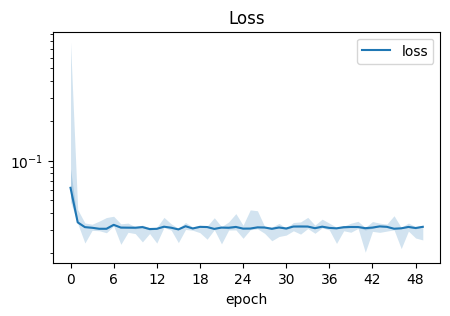

In [ ]:
tinstr.plot_train_history(history)

This is looking a little more promising. Perhaps after training it for a few hundred epochs it will suddenly "click" and start descending rapidly.
But let's have a look at our metrics...

In [ ]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = cross_attention_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=10, callbacks=[variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

x_attn: (None, 128, 256)
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.1534


Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0341
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0317
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0317
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0318
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0308
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0316
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0314
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0308
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0306


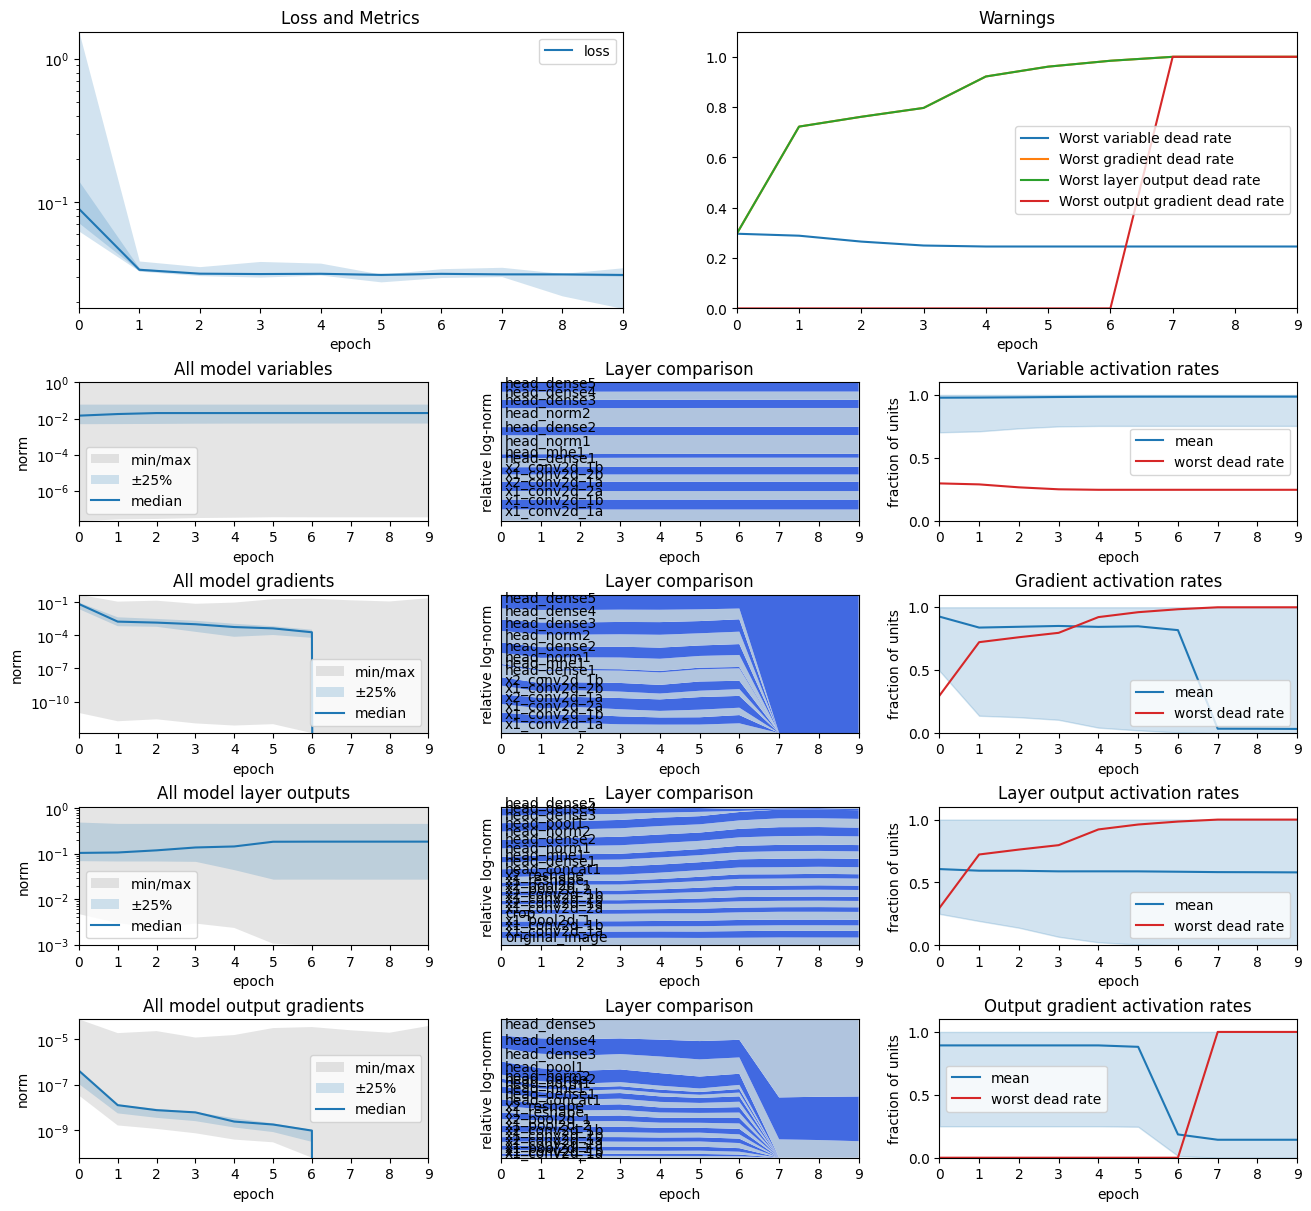

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

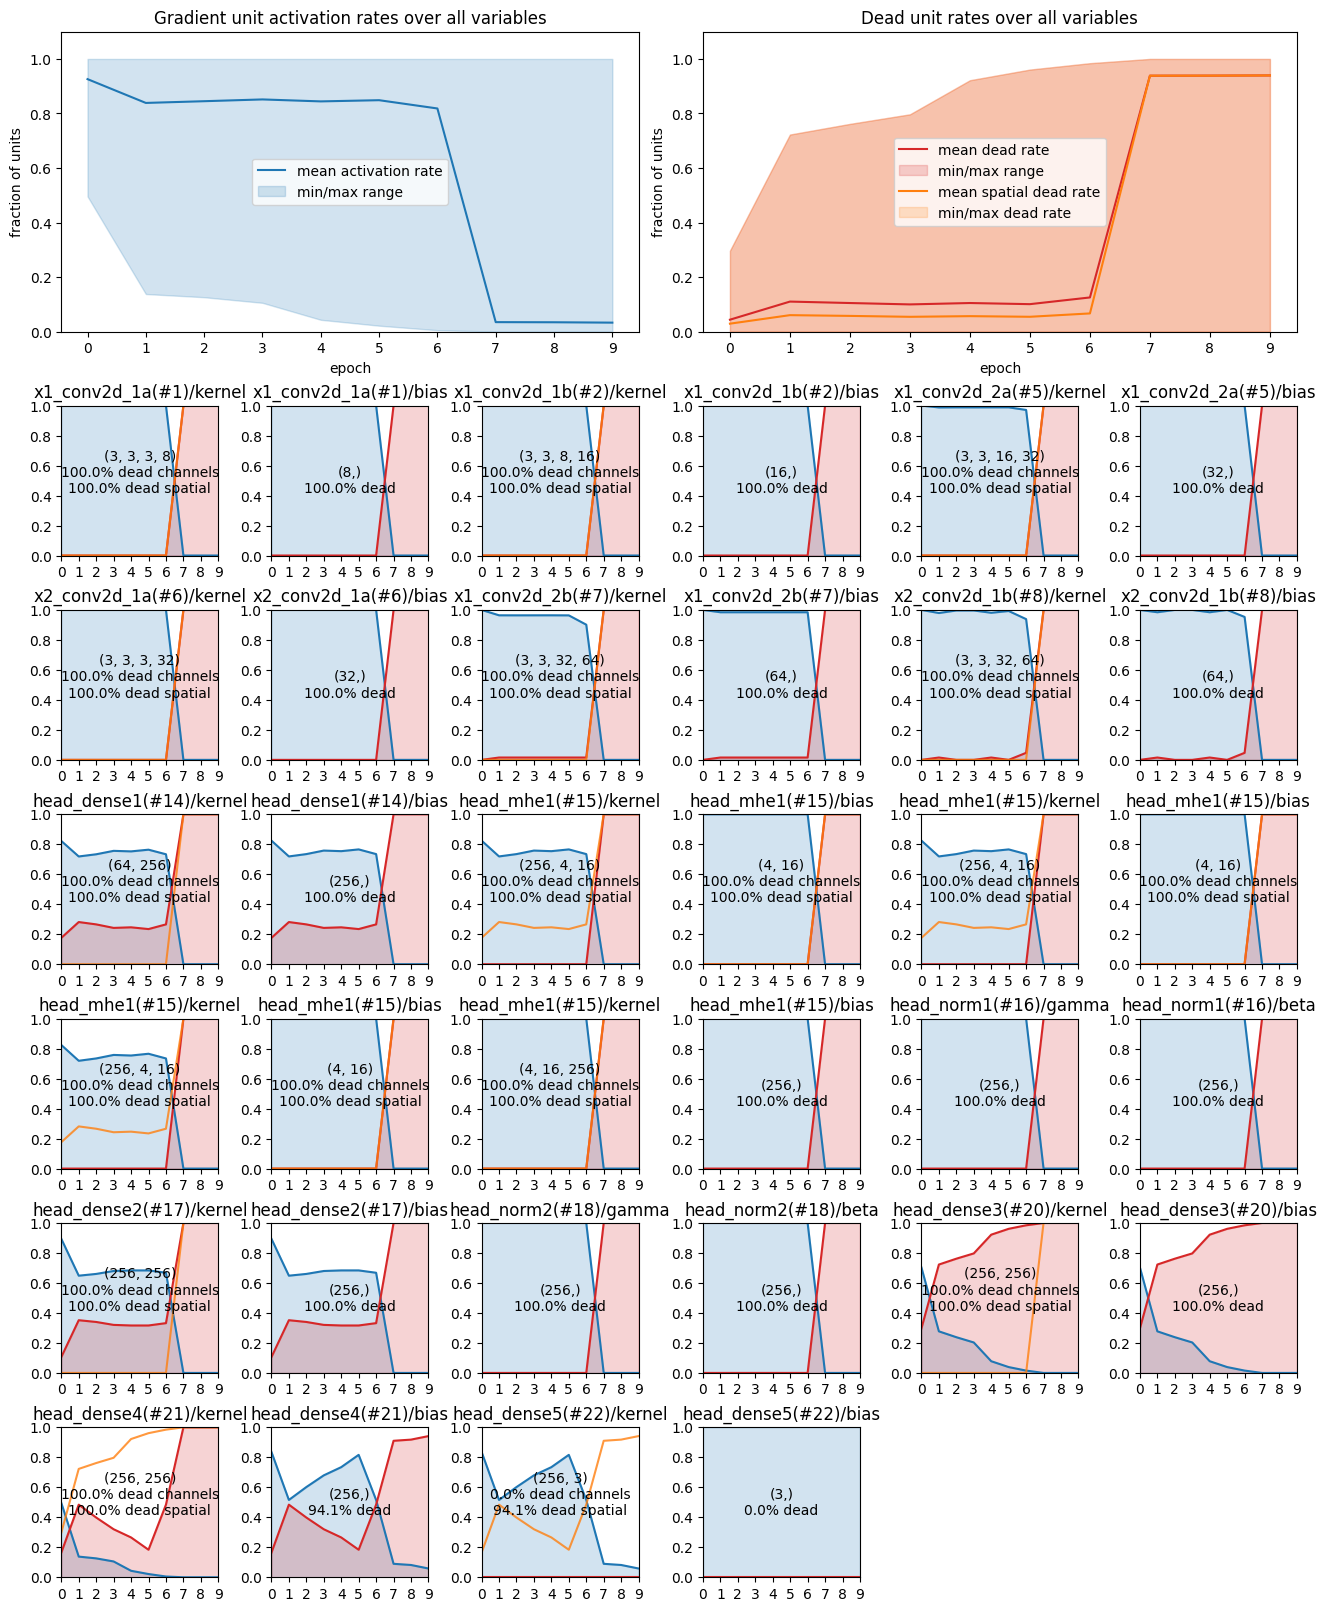

In [ ]:
tinstr.plot_activity_history(gradients)

On first glance this doesn't look much better. But there is some hope:
* significantly fewer layers reach high neuron death within the first epoch.
* while many other layers reach high (even 100%) neuron death, that happens later...which is usually a sign that they were merely caused by gradient collapse within the network due to the earlier layers to have high neuron death.

There's a few things to try now:
* a common strategy to improve resilience in networks is to add `dropout`. This ensures that any given feature can't be encoded by only a single neuron. So it should lead to more neurons remaining active.
* it's also possible that our model is simply too large for the problem at hand.

## Solution 2 - Dropout
We'll try adding dropout first. Specifically, the following layers exihibit particularly strong neuron death rates:
* `head_dense1`
* `head_dense2`
* `head_dense3`
* `head_dense4`

In the current model the first sits more or less on its own, while the other 3 are in a line. So let's be conservative and add dropout after just `head_dense1` and `head_dense4`.

A quick note on interpretation of the activity plots first:
* A question might arise whether dropout will lead to an increase in reported neuron death in the activity plots. Dropout is applied randomly to each row training sample independently. Thus, within a batch of 32 samples, each sample will have a different dropout mask. When computing activity on a per-epoch basis, neuron activity and death is computed across all samples in the epoch. The average activity rate will be reduced slightly by dropout. However the neuron death rate will not generally be affected. In practice, I've seen that layers with already low activity rates are more susceptible to such an effect and will have their neuron death rate increased very slightly - on the order of 1% extra neuron death due to a 20 to 50% dropout.

In [ ]:
def cross_attention_conv_model_with_dropout(dropout_rate=0.2):
    original_input = tf.keras.Input(shape=(32, 32, 3), name="original_image")
    crop_input = tf.keras.Input(shape=(16, 16, 3), name="crop")

    # A CNN stack for the 32x32 original image
    # - 32x32x3 -> 16x16x8 -> 8x8x16 -> 64x16
    x1 = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1a')(original_input)
    x1 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_1')(x1)
    x1 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2a')(x1)
    x1 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2b')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_2')(x1)
    x1 = layers.Reshape((-1, 64), name='x1_reshape')(x1)

    # Separate CNN stack for the 16x16 cropped input
    # - 16x16x3 -> 8x8x16 -> 64x16
    x2 = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1a')(crop_input)
    x2 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1b')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_1')(x2)
    x2 = layers.Reshape((-1, 64), name='x2_reshape')(x2)

    # Add positional encodings for an 8×8 grid
    pos_emb_8x8 = position_encoding(8, 8, 64)
    x1 = x1 + pos_emb_8x8
    x2 = x2 + pos_emb_8x8

    # Cross self-attention
    # - technically this is "joint self-attention"
    x = layers.Concatenate(axis=1, name='head_concat1')([x1, x2])
    x = layers.Dense(256, activation='relu', name='head_dense1')(x)
    x = layers.Dropout(dropout_rate, name='head_dropout1')(x)
    x_attn = layers.MultiHeadAttention(num_heads=4, key_dim=16, name='head_mhe1')(x, x)
    x_attn = layers.LayerNormalization(name='head_norm1')(x_attn + x)
    x_ff = layers.Dense(256, activation='relu', name='head_dense2')(x_attn)
    print(f"x_attn: {x_attn.shape}")
    x = layers.LayerNormalization(name='head_norm2')(x_attn + x_ff)

    # Final regression head
    # - 64x256 -> 256 -> 3 (dx, dy, da)
    x = layers.GlobalAveragePooling1D(name='head_pool1')(x)
    x = layers.Dense(256, activation='relu', name='head_dense3')(x)
    x = layers.Dense(256, activation='relu', name='head_dense4')(x)
    x = layers.Dropout(dropout_rate, name='head_dropout2')(x)
    out = layers.Dense(3, activation='linear', name='head_dense5')(x)

    return tf.keras.Model(inputs=[original_input, crop_input], outputs=out)

# Uncomment if you just want to see the model summary
cross_attention_conv_model_with_dropout().summary()

x_attn: (None, 128, 256)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ original_image            │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1a (Conv2D)     │ (None, 32, 32, 8)      │            224 │ original_image[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1b (Conv2D)     │ (None, 32, 32, 16)     │          1,168 │ x1_conv2d_1a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_1               │ (None, 16, 16, 16)     │              0 │ x1_conv2d_1b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ crop (InputLayer)         │ (None, 16, 16, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2a (Conv2D)     │ (None, 16, 16, 32)     │          4,640 │ x1_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1a (Conv2D)     │ (None, 16, 16, 32)     │            896 │ crop[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2b (Conv2D)     │ (None, 16, 16, 64)     │         18,496 │ x1_conv2d_2a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1b (Conv2D)     │ (None, 16, 16, 64)     │         18,496 │ x2_conv2d_1a[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_2               │ (None, 8, 8, 64)       │              0 │ x1_conv2d_2b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_pool2d_1               │ (None, 8, 8, 64)       │              0 │ x2_conv2d_1b[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_reshape (Reshape)      │ (None, 64, 64)         │              0 │ x1_pool2d_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_reshape (Reshape)      │ (None, 64, 64)         │              0 │ x2_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 64, 64)         │              0 │ x1_reshape[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 64, 64)         │              0 │ x2_reshape[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ head_concat1              │ (None, 128, 64)        │              0 │ add_4[0][0],           │
│ (Concatenate)             │                        │                │ add_5[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ head_dense1 (Dense)       │ (None, 128, 256)       │         16,640 │ head_concat1[0][0]     │
├──────────────────────

 Total params: 325,715 (1.24 MB)

 Trainable params: 325,715 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = cross_attention_conv_model_with_dropout(dropout_rate=0.8)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=10, callbacks=[variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

x_attn: (None, 128, 256)
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.0498


Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0317
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0319
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0321
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0309
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0314
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0306
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0321
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0323
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0312


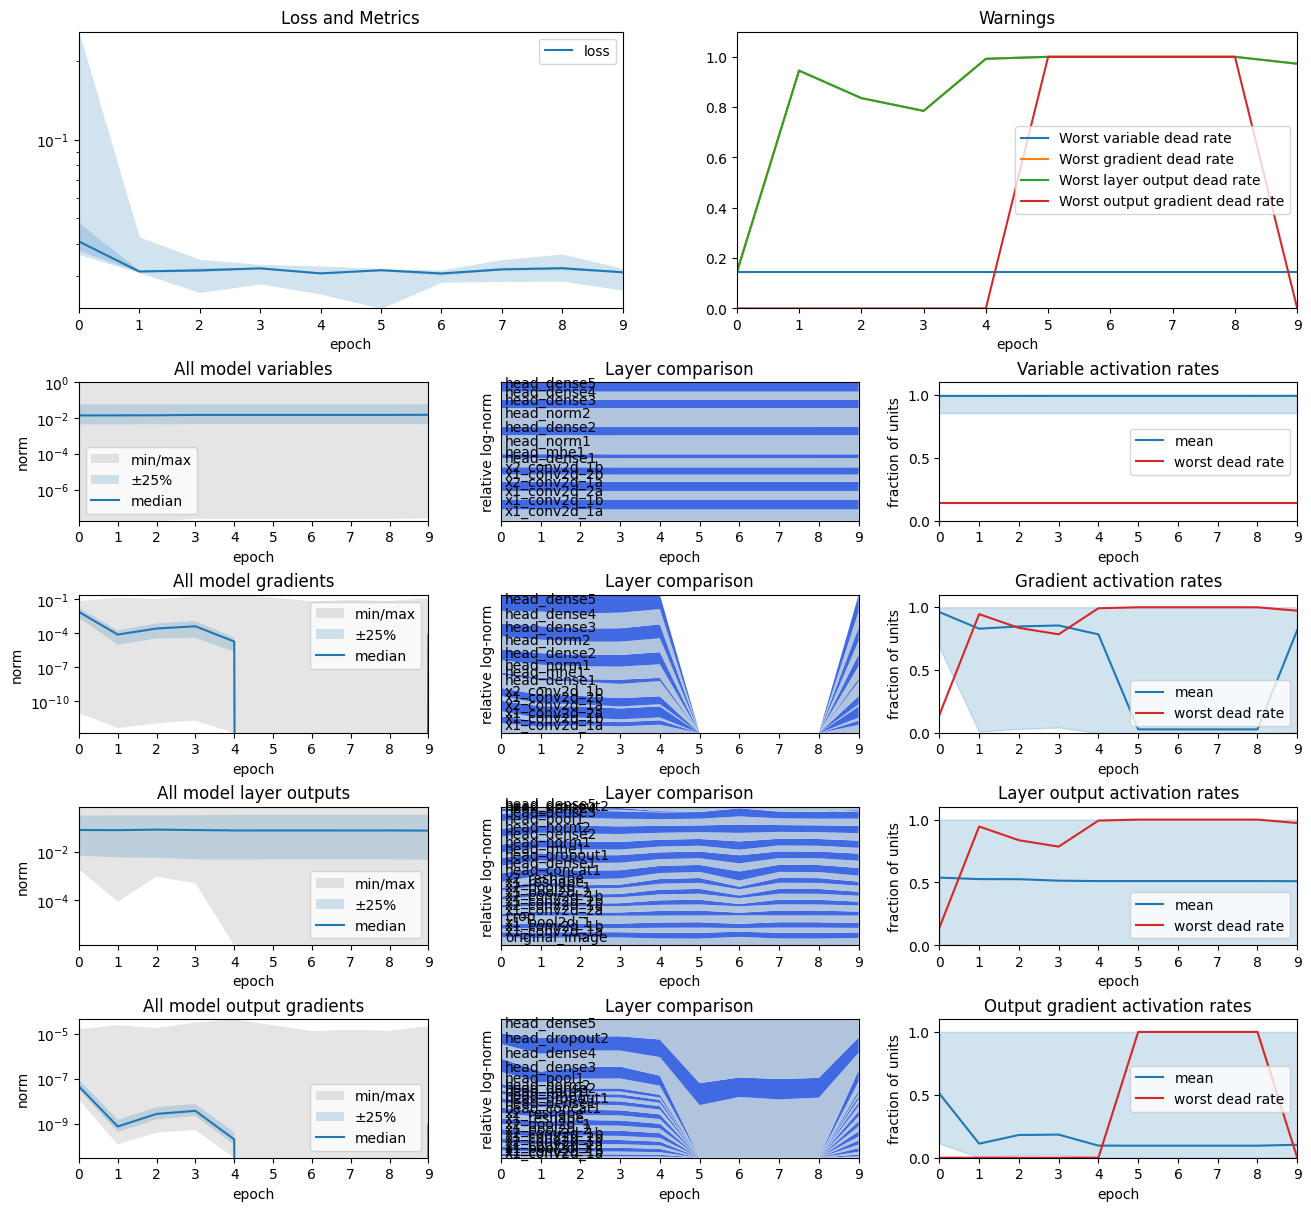

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

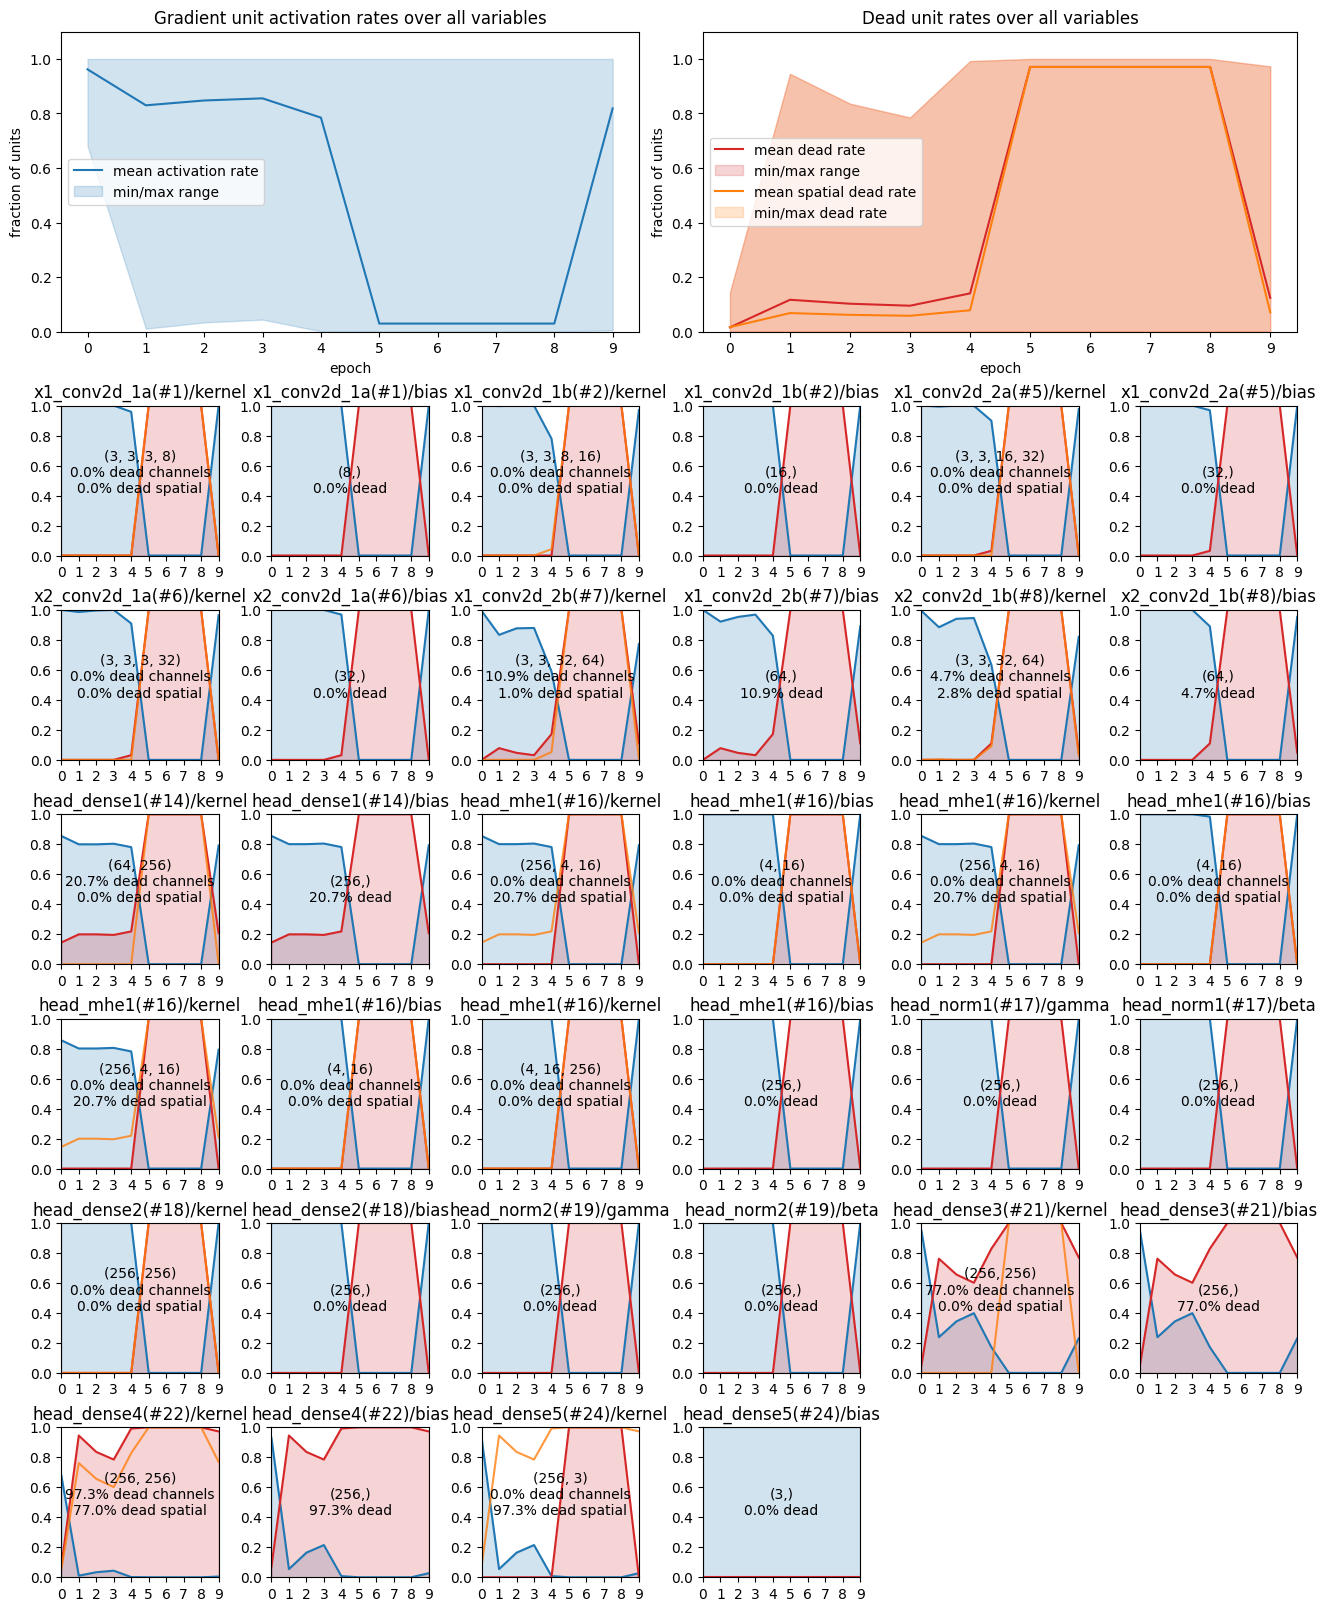

In [ ]:
tinstr.plot_activity_history(gradients)

## Solution 2 - Simpler model
It turns out that part of the problem is that the above model has too much capacity. We can actually reduce loss with a simpler model.

In [ ]:
def simpler_conv_model():
    original_input = tf.keras.Input(shape=(32, 32, 3), name="original_image")
    crop_input = tf.keras.Input(shape=(16, 16, 3), name="crop")

    # A CNN stack for the 32x32 original image
    # - 32x32x3 -> 16x16x32 -> 8x8x64 -> 4096 -> 128
    x1 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1')(original_input)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_1')(x1)
    x1 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_2')(x1)
    x1 = layers.Flatten(name='x1_flatten')(x1)
    x1 = layers.Dense(128, activation='relu', name='x1_dense_1')(x1)

    # Separate CNN stack for the 16x16 cropped input
    # - 16x16x3 -> 8x8x32 -> 4x4x64 -> 1024 -> 128
    x2 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1')(crop_input)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_1')(x2)
    x2 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_2')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_2')(x2)
    x2 = layers.Flatten(name='x2_flatten')(x2)
    x2 = layers.Dense(128, activation='relu', name='x2_dense_1')(x2)

    # Combine feature vectors
    # - 128 + 128 -> 256 -> 3 (dx, dy, da)
    out = layers.Concatenate(name='head_concat1')([x1, x2])
    out = layers.Dense(3, activation='linear', name='head_dense1')(out)

    return tf.keras.Model(inputs=[original_input, crop_input], outputs=out)
